<a href="https://colab.research.google.com/github/SergeiVKalinin/camm_hackathon/blob/k4my4r/docs/day_11_10042026/CAMM_Hackaton_11_Kalinin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Active Experimental Design under Noise and Budget Constraints

In many experiments we aim to discover how a property depends on composition or processing conditions. This is often a case for characterization by XRD, SPM, Raman etc. of spread combinatorial libraries, where a continuous range of compositions is explored on a single substrate.

A mainstream approach for automating such experiments is Bayesian optimization (BO), where a surrogate model (e.g. Gaussian process) is used to predict the property and guide the selection of the next measurement in an active, closed-loop manner.

However, classical BO typically assumes idealized conditions and does not explicitly account for key experimental constraints, such as:

- measurement noise that depends on acquisition time,
- limited experimental budget,
- and cost of moving between measurement locations.

In this challenge, the goal is to design a strategy that, using a surrogate model, decides:

- **where to measure**,
- **in what order**,
- and **for how long**,

in order to efficiently explore and recover the underlying functional dependence under these realistic conditions.

###gif_Classical BO with GP surrogate model



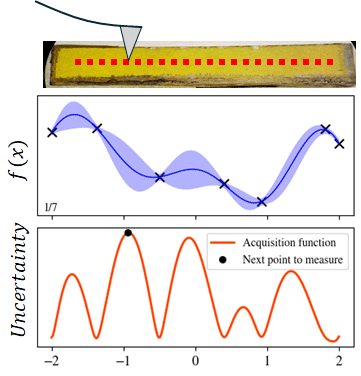

## Functions

In [46]:
!pip install gpytorch

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import gpytorch

In [48]:
#@title target function

# F1 — Smooth unimodal
def unimodal(x):
    x = np.asarray(x)
    res = 0.15 * (x + 2)**2 + 0.03 * (x - 1)**4
    return res #res/res.max()


# F2 — Double-well
def double_well(x):
    x = np.asarray(x)
    res = 0.08 * (x**2 - 4)**2 + 0.15 * x

    return res #res/res.max()


# F3 — Multimodal (Rastrigin-like, 1D)
def multimodal(x):
    x = np.asarray(x)
    res = 10 + x**2 - 7 * np.cos(2 * np.pi * x) + 9 * np.sin(1.4 * np.pi * x)
    return res #res/res.max()


# F4 — Broad + narrow minima
def broad_narrow(x):
    x = np.asarray(x)

    res = (
        1
        - 1.0 * np.exp(-((x + 1.5)**2) / (2 * 0.9**2))
        - 1.6 * np.exp(-((x - 1.0)**2) / (2 * 0.18**2))
    )
    return res #res/res.max()

In [49]:
#@title simple noise models

def noise_constant(x = None, t = None, sigma0=0.1):
    t = np.asarray(t)
    return sigma0 * np.ones_like(t, dtype=float)

def noise_decay_floor(x = None, t = None, sigma_min=0.05, A=0.18, tau=1.0):
    t = np.asarray(t)
    return sigma_min + A * np.exp(-t / tau)

In [50]:
#@title heteroskedastic_noise_model

def make_heteroskedastic_noise_model(f, xlim, n_grid=200, smooth_window=3):
    """
    Build heteroskedastic noise model on a fixed domain.

    Parameters
    ----------
    f : callable
        Ground truth function
    xlim : tuple (xmin, xmax)
        Domain of interest
    """

    xmin, xmax = xlim
    x_grid = np.linspace(xmin, xmax, n_grid)
    y_grid = f(x_grid)

    # gradient
    grad = np.abs(np.gradient(y_grid, x_grid, edge_order=2))

    # smoothing
    if smooth_window > 1:
        kernel = np.ones(smooth_window) / smooth_window
        half = smooth_window // 2
        grad_s = np.pad(grad, pad_width=half, mode="reflect")
        grad = np.convolve(grad_s, kernel, mode="valid")

    # normalization
    scale = np.percentile(grad, 95) + 1e-12
    grad_norm_grid = grad / scale

    def noise_model(x, t, sigma_min=0.05, sigma_max=0.5, tau=1.5):
        x = np.asarray(x, dtype=float)
        t = np.asarray(t, dtype=float)

        g = np.interp(x, x_grid, grad_norm_grid)
        sigma0_x = sigma_min + (sigma_max - sigma_min) * g

        return sigma_min + (sigma0_x - sigma_min) * np.exp(-t / tau)

    return noise_model

In [51]:
#@title measurement simulator

class MeasurementSimulator:
    def __init__(self, ground_truth_model, noise_model, rng=None, **noise_kwargs):
        """
        Parameters
        ----------
        ground_truth_model : callable
            Function f(x)
        noise_model : callable
            Function sigma(x, t, **noise_kwargs)
        rng : None, int, or np.random.Generator
            Random generator or seed
        **noise_kwargs
            Default parameters for noise_model
        """
        self.f = ground_truth_model
        self.noise_model = noise_model
        self.noise_kwargs = noise_kwargs

        if rng is None:
            self.rng = np.random.default_rng()
        elif isinstance(rng, (int, np.integer)):
            self.rng = np.random.default_rng(rng)
        else:
            self.rng = rng

    def measure(self, coords, **noise_kwargs):
        """
        coords : array of shape (N, 2)
            Columns are (x, t)

        Returns
        -------
        y_meas : array of shape (N,)
            Noisy measurements
        """
        coords = np.asarray(coords, dtype=float)

        if coords.ndim != 2 or coords.shape[1] != 2:
            raise ValueError("coords must have shape (N, 2)")

        x = coords[:, 0]
        t = coords[:, 1]

        kwargs = {**self.noise_kwargs, **noise_kwargs}
        sigma = np.asarray(self.noise_model(x, t, **kwargs), dtype=float)
        noise = self.rng.normal(0.0, sigma, size=len(x))

        return self.f(x) + noise

    __call__ = measure

In [52]:
#@title gp functions

import torch
import gpytorch


def gp_predict(x_train, y_train, x_test, training_iter=100, lr=0.1):
    """
    Fit GP on (x_train, y_train) and predict on x_test.

    Parameters
    ----------
    x_train : array-like (N,)
    y_train : array-like (N,)
    x_test  : array-like (M,)

    Returns
    -------
    mean : (M,)
    std  : (M,)
    """

    # convert to torch
    x_train = torch.as_tensor(x_train, dtype=torch.float32)
    y_train = torch.as_tensor(y_train, dtype=torch.float32)
    x_test  = torch.as_tensor(x_test, dtype=torch.float32)

    # ensure 2D inputs
    if x_train.ndim == 1:
        x_train = x_train.unsqueeze(-1)
    if x_test.ndim == 1:
        x_test = x_test.unsqueeze(-1)

    # define model
    likelihood = gpytorch.likelihoods.GaussianLikelihood()

    class GPModel(gpytorch.models.ExactGP):
        def __init__(self, train_x, train_y, likelihood):
            super().__init__(train_x, train_y, likelihood)
            self.mean_module = gpytorch.means.ConstantMean()
            self.covar_module = gpytorch.kernels.ScaleKernel(
                gpytorch.kernels.RBFKernel()
            )

        def forward(self, x):
            mean = self.mean_module(x)
            covar = self.covar_module(x)
            return gpytorch.distributions.MultivariateNormal(mean, covar)

    model = GPModel(x_train, y_train, likelihood)

    # train
    model.train()
    likelihood.train()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

    for _ in range(training_iter):
        optimizer.zero_grad()
        output = model(x_train)
        loss = -mll(output, y_train)
        loss.backward()
        optimizer.step()

    # predict
    model.eval()
    likelihood.eval()

    with torch.no_grad():
        pred = likelihood(model(x_test))
        mean = pred.mean.cpu().numpy()
        std = pred.stddev.cpu().numpy()

    return mean, std

In [53]:
#@title cost models

def travel_cost(dx, speed=0.5) -> float:
  return abs(dx) / speed


## Introduction

In [54]:
x = np.linspace(-4,4,100) #spatial coordinate (compositional/parameter space)
t = np.linspace(0,10,100) #acquisition time

We suggest selecting one of the following four “ground truth” functions to represent the underlying functionality.

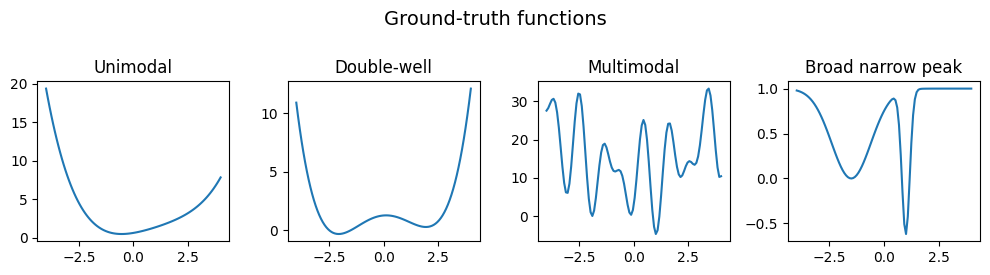

In [55]:
#ground truth functions
fig, ax = plt.subplots(1,4, figsize=(10, 2.7))

ax[0].plot(x, unimodal(x))
ax[1].plot(x, double_well(x))
ax[2].plot(x, multimodal(x))
ax[3].plot(x, broad_narrow(x))

ax[0].set_title('Unimodal')
ax[1].set_title('Double-well')
ax[2].set_title('Multimodal')
ax[3].set_title('Broad narrow peak')

fig.suptitle('Ground-truth functions', y=1, fontsize=14)

plt.tight_layout()

To emulate noisy measurements, we consider two homoscedastic noise models. The first is a **constant noise** model (trivial case), where the measurement precision is independent of acquisition time. The second is a **decaying noise** model, where the noise decreases exponentially with acquisition time and approaches a maximum achievable precision.

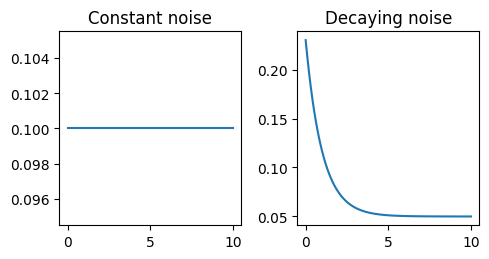

In [56]:
#homoskedastic noise model

fig, ax = plt.subplots(1,2, figsize=(5, 2.7))

ax[0].plot(t, noise_constant(x, t))
ax[0].set_title('Constant noise')
ax[1].plot(t, noise_decay_floor(x, t))
ax[1].set_title('Decaying noise')

plt.tight_layout()

For those seeking more hardcore challenge, we also suggest a **heteroscedastic noise model**, where the measurement noise depends on the location. In our specific case, the noise level is proportional to the local gradient of the underlying function, while still decaying with acquisition time toward a limiting precision.

Text(0.5, 0.98, 'Heteroskedastic noise model')

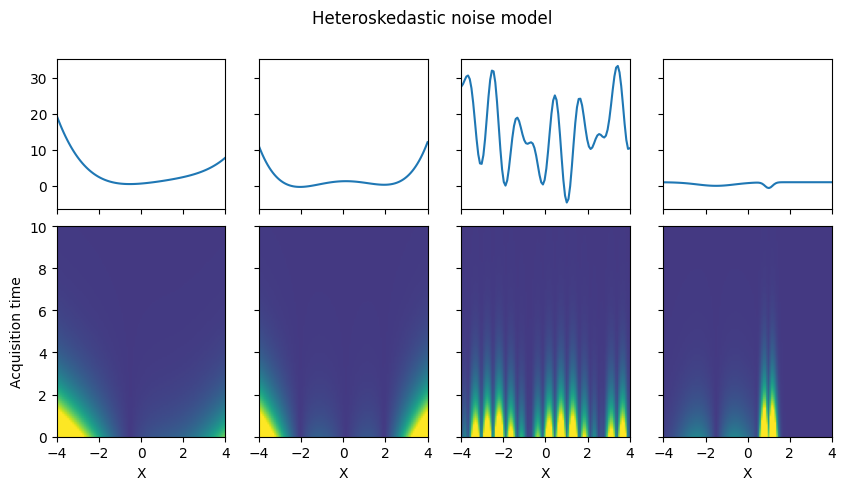

In [57]:
#@title heteroskedastic noise model

funcs = [unimodal, double_well, multimodal, broad_narrow]

fig, ax = plt.subplots(2, 4, figsize=(10, 5),
                       height_ratios=(1,1.5),
                       sharex=True,
                       sharey='row',
                       gridspec_kw={'hspace': 0.05})

for i,ax0_ in enumerate(ax[0]):
  ax0_.plot(x, funcs[i](x))

for i,ax1_ in enumerate(ax[1]):
  noise_model = make_heteroskedastic_noise_model(funcs[i], (-4, 4))
  ax1_.imshow(noise_model(x, t.reshape(-1,1)),
              origin='lower',
              extent=[x.min(), x.max(), t.min(), t.max()],
              vmax=.3, vmin=0)
  ax1_.set_xlabel('X')

ax[1,0].set_ylabel('Acquisition time')

fig.suptitle('Heteroskedastic noise model')


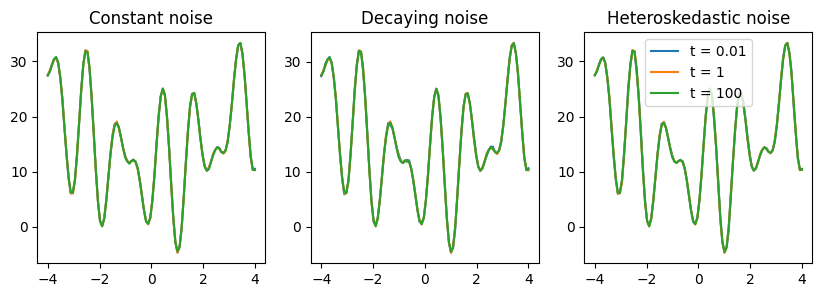

In [58]:
#@title example: grid measurements with different acqusition time

x = np.linspace(-4,4, 100) #x grid

durations = [0.01, 1, 100] #select durations
model = multimodal #select model [unimodal, double_well, multimodal, broad_narrow]

noise_heter_model = make_heteroskedastic_noise_model(model, (-4, 4))

sim_const = MeasurementSimulator(
    ground_truth_model=model,
    noise_model=noise_constant,
    rng=123,
)

sim_decay = MeasurementSimulator(
    ground_truth_model=model,
    noise_model=noise_decay_floor,
    rng=123,
)

sim_heterosk = MeasurementSimulator(
    ground_truth_model=model,
    noise_model=noise_heter_model,
    rng=123,
)

fig, ax = plt.subplots(1, 3, figsize=(10,3))

for d in durations:
  d_ar = np.ones(len(x))*d
  coords = np.vstack([x, d_ar]).T

  ax[0].plot(coords[:,0], sim_const.measure(coords), label = f't = {d}')
  ax[1].plot(coords[:,0], sim_decay.measure(coords), label = f't = {d}')
  ax[2].plot(coords[:,0], sim_heterosk.measure(coords), label = f't = {d}')

ax[0].set_title('Constant noise')
ax[1].set_title('Decaying noise')
ax[2].set_title('Heteroskedastic noise')
ax[2].legend()

In [59]:
#@title example: surrogate modeling

#homoskedatic noise model: [noise_constant, noise_decay_floor]
#ground truth models: [unimodal, double_well, multimodal, broad_narrow]


#If we select the heteroskedastic noise model, we first need to construct it. For the homoskedastic cases, the models are already defined.
noise_heter_model = make_heteroskedastic_noise_model(double_well, xlim=(-4, 4)) #please define the x range

meas_sim = MeasurementSimulator(
    ground_truth_model=double_well,
    noise_model=noise_heter_model,
    rng=123,
)

In [60]:

#define x_grid on the explored interval

x_grid = np.linspace(-4, 4, 500)

# For this example, select 4 random locations in the range (-4, 4)
x = np.random.random(7) * 8 - 4

# Set acquisition time (t = 3) for all locations
t = np.ones(len(x)) * 1

# Form the coordinate array: [[x1, t1], [x2, t2], ...]
coords = np.column_stack([x, t])

#make "measurements"
y = meas_sim.measure(coords)

#surrogate modeling
mean, std = gp_predict(x, y, x_grid, training_iter=100, lr=0.1)

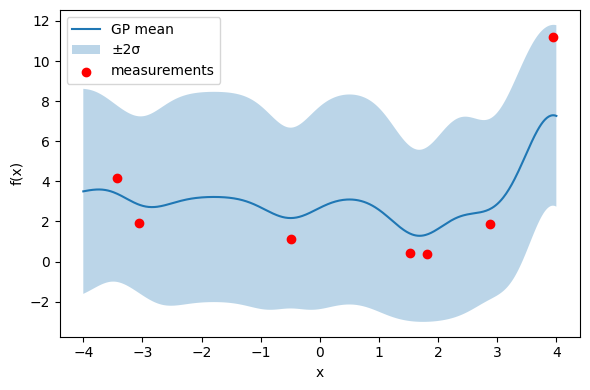

In [61]:
plt.figure(figsize=(6, 4))

# GP mean
plt.plot(x_grid, mean, label="GP mean")

# uncertainty band
plt.fill_between(
  x_grid,
  mean - 2 * std,
  mean + 2 * std,
  alpha=0.3,
  label="±2σ"
)

# training points
plt.scatter(x, y, color="red", zorder=3, label="measurements")

plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.tight_layout()
plt.show()

For simplicity, we treat time as the cost function. The cost of a single measurement is therefore equal to its acquisition time. In addition, we introduce a travel cost, which accounts for moving between measurement locations and is assumed to be proportional to the distance between them.

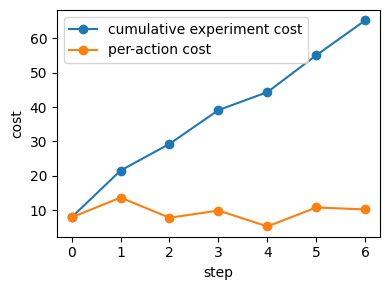

In [62]:
#@title total experiment cost

# initial position
x0 = 0

# displacement between consecutive points (including first move from x0)
dx = x - np.append(x0, x[:-1])

# cost of each action = travel cost + acquisition time
action_costs = travel_cost(dx) + t

# visualize costs
fig = plt.figure(figsize=(4,3))
plt.plot(np.cumsum(action_costs), 'o-', label='cumulative experiment cost')
plt.plot(action_costs, 'o-', label='per-action cost')

plt.xlabel('step')
plt.ylabel('cost')
plt.legend()
plt.tight_layout()




---


## Lets go!
---



Design a strategy that selects where to measure, in what order, and for how long, using the provided simulator and a fixed total budget. The objective is to explore or optimize the underlying function as efficiently as possible under noisy measurements and movement cost.

In [63]:
B = 100 #your budget

meas_sim = MeasurementSimulator(
    ground_truth_model=broad_narrow, #choose gt function
    noise_model=noise_constant, #noise_decay_floor,  #choose noise model
    rng=123,
)

In [64]:
x_grid = np.linspace(-4, 4, 500)
x = np.random.random(20) * 8 - 4
t = np.ones(len(x)) * 5
coords = np.column_stack([x, t])
y = meas_sim.measure(coords)
mean, std = gp_predict(x, y, x_grid, training_iter=100, lr=0.1)

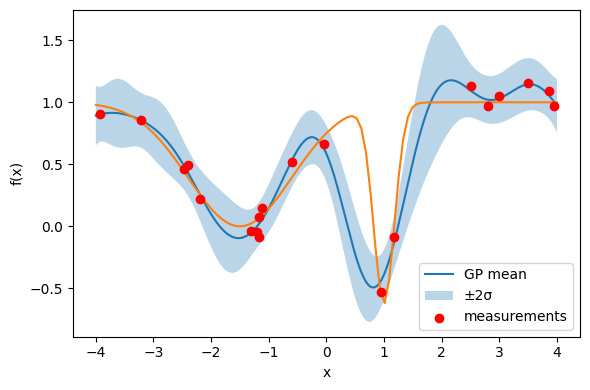

In [65]:
plt.figure(figsize=(6, 4))
plt.plot(x_grid, mean, label="GP mean")

plt.fill_between(
  x_grid,
  mean - 2 * std,
  mean + 2 * std,
  alpha=0.3,
  label="±2σ"
)

plt.scatter(x, y, color="red", zorder=3, label="measurements")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.tight_layout()

x1 = np.linspace(-4,4,100)
plt.plot(x1, broad_narrow(x1))

plt.show()

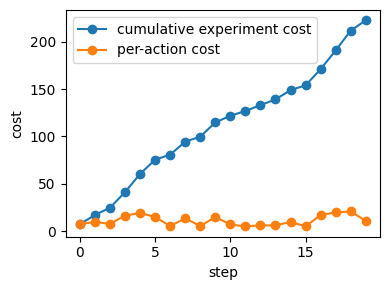

In [66]:
x0 = 0
dx = x - np.append(x0, x[:-1])
action_costs = travel_cost(dx) + t

fig = plt.figure(figsize=(4,3))
plt.plot(np.cumsum(action_costs), 'o-', label='cumulative experiment cost')
plt.plot(action_costs, 'o-', label='per-action cost')
plt.xlabel('step')
plt.ylabel('cost')
plt.legend()
plt.tight_layout()

# Equi-time search

Equal spacing in space, and use the GP for reconstruction on preset positions

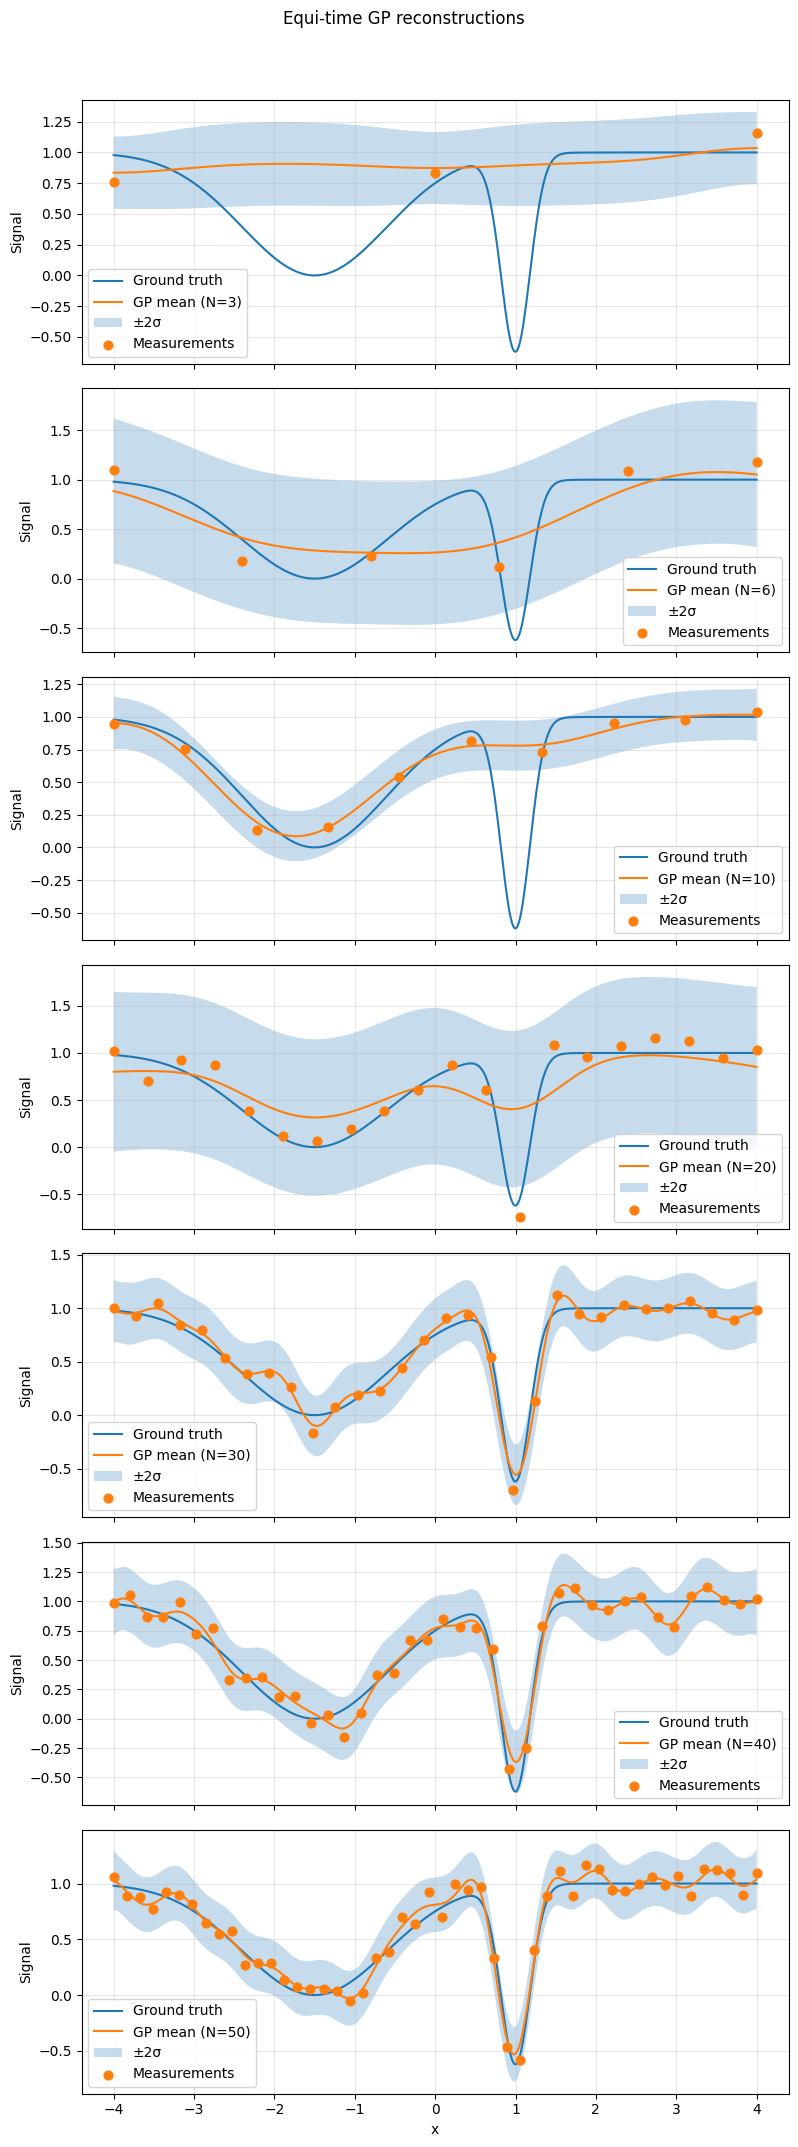

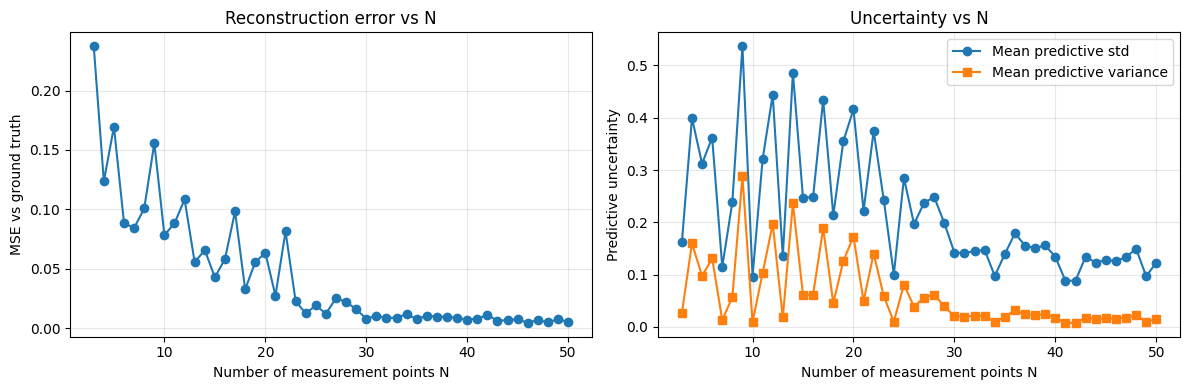

Best N by MSE         : 46  (MSE = 0.00439734)
Best N by mean std    : 41  (mean std = 0.0883842)


In [67]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Assumptions:
#   B            : total campaign budget
#   meas_sim     : MeasurementSimulator instance
#   gp_predict   : function gp_predict(x, y, x_grid, training_iter=..., lr=...)
#   x_grid       : dense evaluation grid
#   broad_narrow : ground-truth callable
# ------------------------------------------------------------

# Ground truth on the evaluation grid
y_true = broad_narrow(x_grid)
Ns = np.arange(3, 51)
all_results = []

for N in Ns:
    # Equally spaced measurement positions across the experimental domain
    x_meas = np.linspace(x_grid.min(), x_grid.max(), N)

    # Equal time allocation
    t_meas = np.ones(N) * (B / N)

    # Query simulator
    coords = np.column_stack([x_meas, t_meas])
    y_meas = meas_sim.measure(coords)

    # GP reconstruction
    mean_pred, std_pred = gp_predict(
        x_meas, y_meas, x_grid,
        training_iter=100,
        lr=0.1
    )

    # Metrics
    mse = np.mean((mean_pred - y_true) ** 2)
    mean_std = np.mean(std_pred)
    mean_var = np.mean(std_pred ** 2)

    all_results.append({
        "N": N,
        "x_meas": x_meas,
        "t_meas": t_meas,
        "y_meas": y_meas,
        "mean_pred": mean_pred,
        "std_pred": std_pred,
        "mse": mse,
        "mean_std": mean_std,
        "mean_var": mean_var,
    })

# Convert summary metrics to arrays
mse_vals = np.array([r["mse"] for r in all_results])
mean_std_vals = np.array([r["mean_std"] for r in all_results])
mean_var_vals = np.array([r["mean_var"] for r in all_results])

# ------------------------------------------------------------
# Plot 1: example reconstructions for a few N values
# ------------------------------------------------------------
example_Ns = [3, 6, 10, 20, 30, 40, 50]

fig, axes = plt.subplots(len(example_Ns), 1, figsize=(8, 3 * len(example_Ns)), sharex=True)

if len(example_Ns) == 1:
    axes = [axes]

for ax, N_show in zip(axes, example_Ns):
    r = next(rr for rr in all_results if rr["N"] == N_show)

    ax.plot(x_grid, y_true, label="Ground truth")
    ax.plot(x_grid, r["mean_pred"], label=f"GP mean (N={N_show})")
    ax.fill_between(
        x_grid,
        r["mean_pred"] - 2 * r["std_pred"],
        r["mean_pred"] + 2 * r["std_pred"],
        alpha=0.25,
        label="±2σ"
    )
    ax.scatter(r["x_meas"], r["y_meas"], s=40, zorder=3, label="Measurements")
    ax.set_ylabel("Signal")
    ax.legend(loc="best")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("x")
fig.suptitle("Equi-time GP reconstructions", y=1.02)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Plot 2: MSE and predictive uncertainty vs N
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(Ns, mse_vals, marker='o')
ax[0].set_xlabel("Number of measurement points N")
ax[0].set_ylabel("MSE vs ground truth")
ax[0].set_title("Reconstruction error vs N")
ax[0].grid(True, alpha=0.3)

ax[1].plot(Ns, mean_std_vals, marker='o', label='Mean predictive std')
ax[1].plot(Ns, mean_var_vals, marker='s', label='Mean predictive variance')
ax[1].set_xlabel("Number of measurement points N")
ax[1].set_ylabel("Predictive uncertainty")
ax[1].set_title("Uncertainty vs N")
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Print best N by each metric
# ------------------------------------------------------------
best_mse_idx = np.argmin(mse_vals)
best_unc_idx = np.argmin(mean_std_vals)

print(f"Best N by MSE         : {Ns[best_mse_idx]}  (MSE = {mse_vals[best_mse_idx]:.6g})")
print(f"Best N by mean std    : {Ns[best_unc_idx]}  (mean std = {mean_std_vals[best_unc_idx]:.6g})")

Active learning for equal spacing

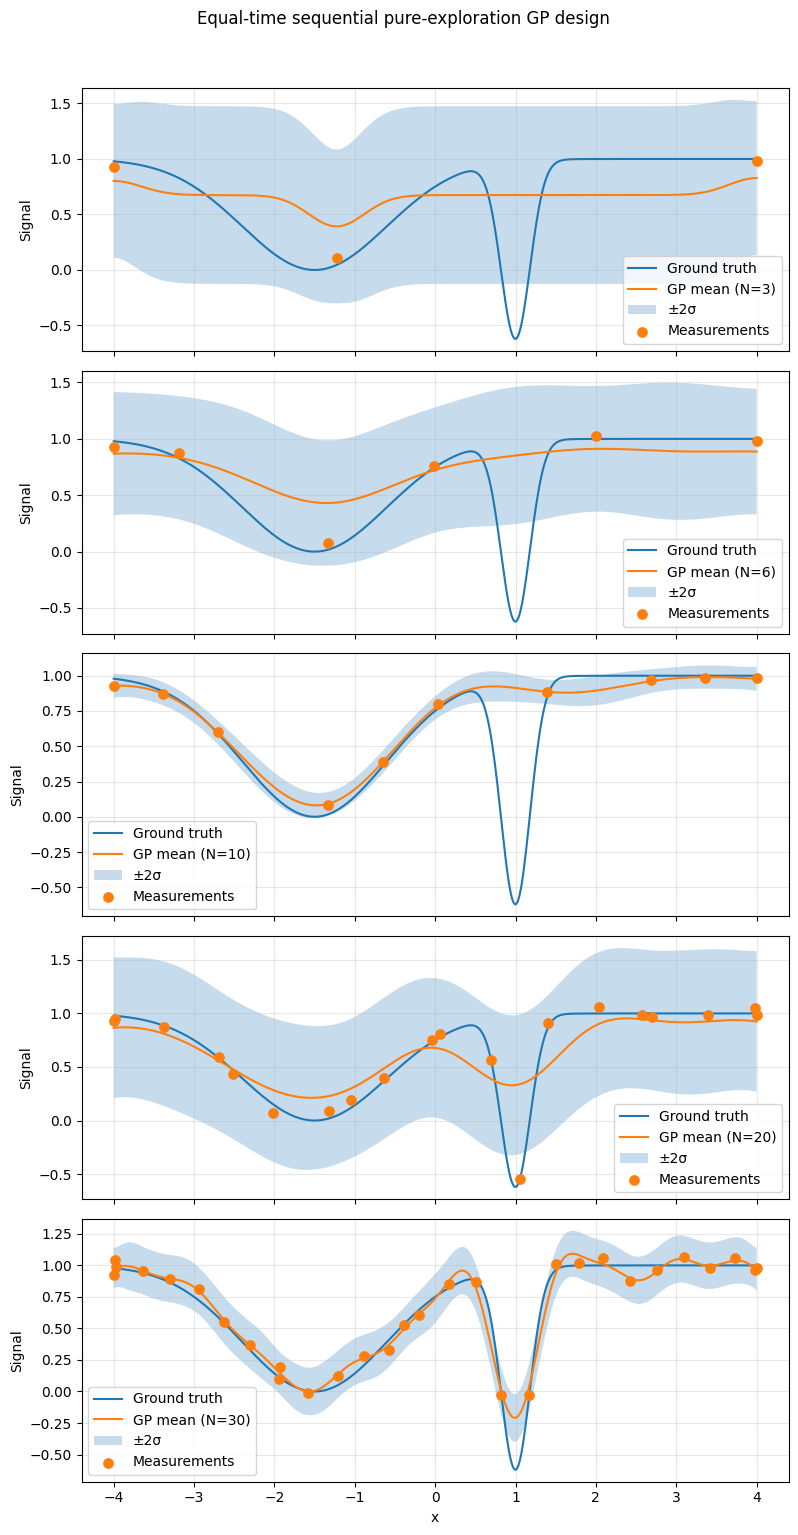

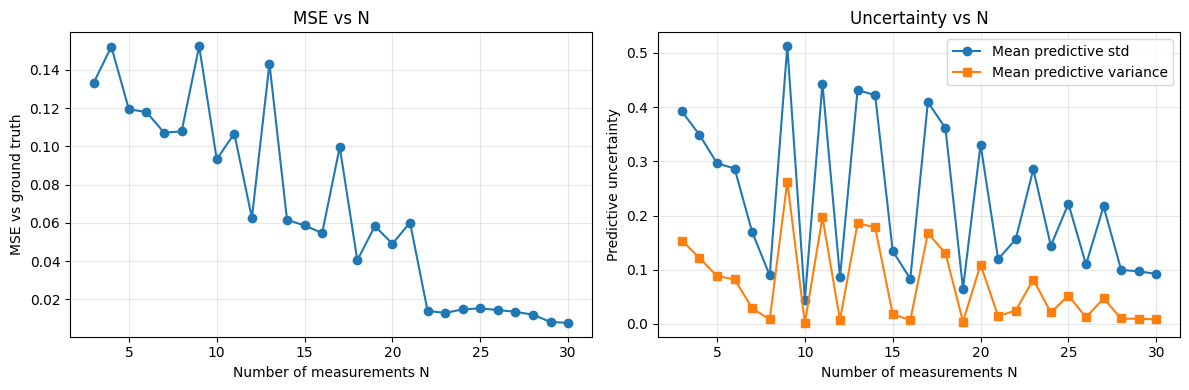

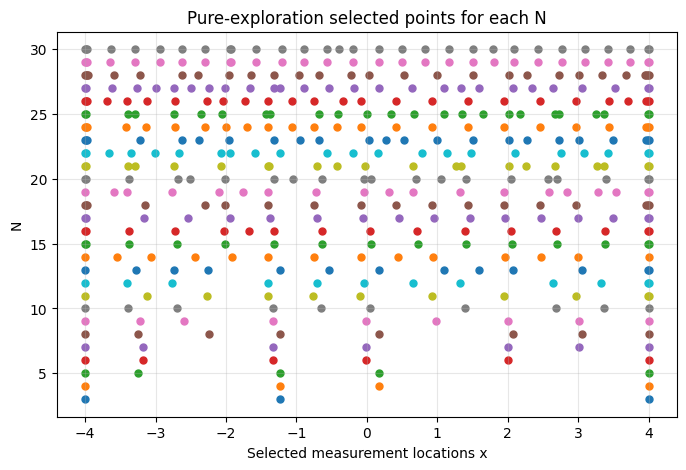

Best N by MSE      : 30  (MSE = 0.0076667)
Best N by mean std : 10  (mean std = 0.0444484)


In [69]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Assumptions already in memory:
#   B
#   MeasurementSimulator
#   broad_narrow
#   noise_decay_floor
#   gp_predict
#   x_grid
# ------------------------------------------------------------

def pure_exploration_next_x(x_obs, std_pred, candidate_x, exclusion_radius=1e-9):
    """
    Choose the next x by maximizing GP predictive std,
    excluding already-sampled locations.
    """
    mask = np.ones_like(candidate_x, dtype=bool)
    for xo in x_obs:
        mask &= np.abs(candidate_x - xo) > exclusion_radius

    if not np.any(mask):
        return None

    idx_local = np.argmax(std_pred[mask])
    return float(candidate_x[mask][idx_local])


def run_equal_time_pure_exploration_for_N(
    N,
    B,
    x_grid,
    gp_predict,
    ground_truth_model,
    noise_model,
    rng_seed=123,
    training_iter=100,
    lr=0.1,
):
    """
    For a fixed N:
      - equal dwell time t = B / N
      - 2 seed points at domain boundaries
      - remaining points selected iteratively by max predictive std
    """
    # Reinitialize simulator so each N run is reproducible
    meas_sim = MeasurementSimulator(
        ground_truth_model=ground_truth_model,
        noise_model=noise_model,
        rng=rng_seed,
    )

    t_each = B / N
    y_true = ground_truth_model(x_grid)

    # Candidate set for acquisition
    candidate_x = x_grid.copy()

    # Seed points: left and right boundaries
    x_obs = [float(x_grid[0]), float(x_grid[-1])]
    t_obs = [t_each, t_each]

    coords0 = np.column_stack([x_obs, t_obs])
    y_obs = list(meas_sim.measure(coords0))

    history = [{
        "step": 1,
        "x": x_obs[0],
        "t": t_each,
        "y": y_obs[0],
        "type": "seed",
    }, {
        "step": 2,
        "x": x_obs[1],
        "t": t_each,
        "y": y_obs[1],
        "type": "seed",
    }]

    # Sequential pure-exploration selection
    for k in range(2, N):
        x_arr = np.asarray(x_obs)
        y_arr = np.asarray(y_obs)

        mean_pred, std_pred = gp_predict(
            x_arr, y_arr, x_grid,
            training_iter=training_iter,
            lr=lr,
        )

        exclusion_radius = 0.5 * (x_grid[1] - x_grid[0])
        x_next = pure_exploration_next_x(
            x_obs=x_arr,
            std_pred=std_pred,
            candidate_x=candidate_x,
            exclusion_radius=exclusion_radius,
        )

        if x_next is None:
            break

        y_next = float(meas_sim.measure(np.array([[x_next, t_each]]))[0])

        x_obs.append(x_next)
        t_obs.append(t_each)
        y_obs.append(y_next)

        history.append({
            "step": k + 1,
            "x": x_next,
            "t": t_each,
            "y": y_next,
            "type": "adaptive",
        })

    # Final GP
    x_arr = np.asarray(x_obs)
    y_arr = np.asarray(y_obs)

    mean_final, std_final = gp_predict(
        x_arr, y_arr, x_grid,
        training_iter=training_iter,
        lr=lr,
    )

    mse = np.mean((mean_final - y_true) ** 2)
    mean_std = np.mean(std_final)
    mean_var = np.mean(std_final ** 2)

    return {
        "N": N,
        "t_each": t_each,
        "x_meas": x_arr,
        "t_meas": np.asarray(t_obs),
        "y_meas": np.asarray(y_obs),
        "mean_pred": mean_final,
        "std_pred": std_final,
        "y_true": y_true,
        "mse": mse,
        "mean_std": mean_std,
        "mean_var": mean_var,
        "history": history,
    }


# ------------------------------------------------------------
# Sweep N = 3..20
# ------------------------------------------------------------
Ns = np.arange(3, 31)

all_results_pe = []

for N in Ns:
    res = run_equal_time_pure_exploration_for_N(
        N=N,
        B=B,
        x_grid=x_grid,
        gp_predict=gp_predict,
        ground_truth_model=broad_narrow,
        noise_model=noise_decay_floor,
        rng_seed=123,         # same seed for reproducibility
        training_iter=100,
        lr=0.1,
    )
    all_results_pe.append(res)

mse_vals = np.array([r["mse"] for r in all_results_pe])
mean_std_vals = np.array([r["mean_std"] for r in all_results_pe])
mean_var_vals = np.array([r["mean_var"] for r in all_results_pe])

# ------------------------------------------------------------
# Plot example reconstructions
# ------------------------------------------------------------
example_Ns = [3, 6, 10, 20, 30]

fig, axes = plt.subplots(len(example_Ns), 1, figsize=(8, 3 * len(example_Ns)), sharex=True)

if len(example_Ns) == 1:
    axes = [axes]

for ax, N_show in zip(axes, example_Ns):
    r = next(rr for rr in all_results_pe if rr["N"] == N_show)

    ax.plot(x_grid, r["y_true"], label="Ground truth")
    ax.plot(x_grid, r["mean_pred"], label=f"GP mean (N={N_show})")
    ax.fill_between(
        x_grid,
        r["mean_pred"] - 2 * r["std_pred"],
        r["mean_pred"] + 2 * r["std_pred"],
        alpha=0.25,
        label="±2σ"
    )
    ax.scatter(r["x_meas"], r["y_meas"], s=45, zorder=3, label="Measurements")
    ax.set_ylabel("Signal")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")

axes[-1].set_xlabel("x")
fig.suptitle("Equal-time sequential pure-exploration GP design", y=1.02)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Plot metrics vs N
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(Ns, mse_vals, marker='o')
ax[0].set_xlabel("Number of measurements N")
ax[0].set_ylabel("MSE vs ground truth")
ax[0].set_title("MSE vs N")
ax[0].grid(True, alpha=0.3)

ax[1].plot(Ns, mean_std_vals, marker='o', label='Mean predictive std')
ax[1].plot(Ns, mean_var_vals, marker='s', label='Mean predictive variance')
ax[1].set_xlabel("Number of measurements N")
ax[1].set_ylabel("Predictive uncertainty")
ax[1].set_title("Uncertainty vs N")
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Optional: show how selected x locations evolve for each N
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
for i, r in enumerate(all_results_pe):
    y_row = np.ones_like(r["x_meas"]) * r["N"]
    plt.scatter(r["x_meas"], y_row, s=25)

plt.xlabel("Selected measurement locations x")
plt.ylabel("N")
plt.title("Pure-exploration selected points for each N")
plt.grid(True, alpha=0.3)
plt.show()

# ------------------------------------------------------------
# Report best N
# ------------------------------------------------------------
best_mse_idx = np.argmin(mse_vals)
best_unc_idx = np.argmin(mean_std_vals)

print(f"Best N by MSE      : {Ns[best_mse_idx]}  (MSE = {mse_vals[best_mse_idx]:.6g})")
print(f"Best N by mean std : {Ns[best_unc_idx]}  (mean std = {mean_std_vals[best_unc_idx]:.6g})")

Equal space exploration with cost

Feasible N values: [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50]


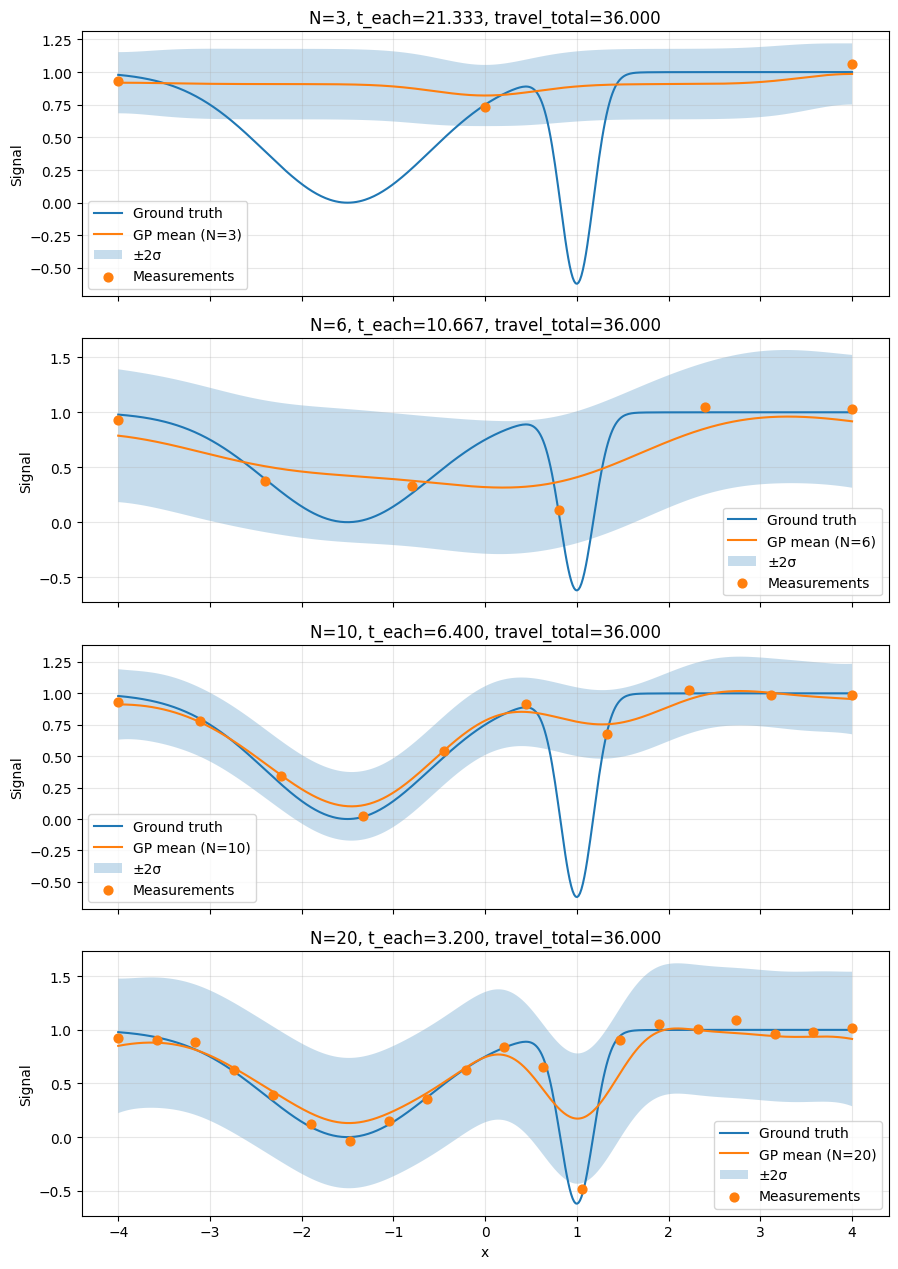

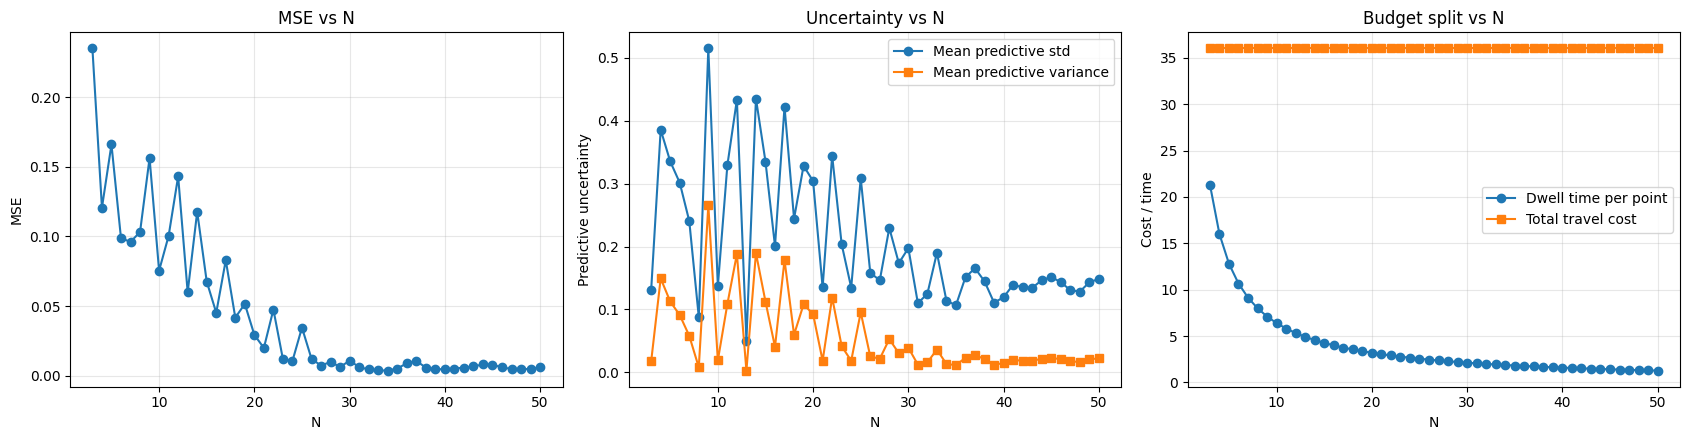

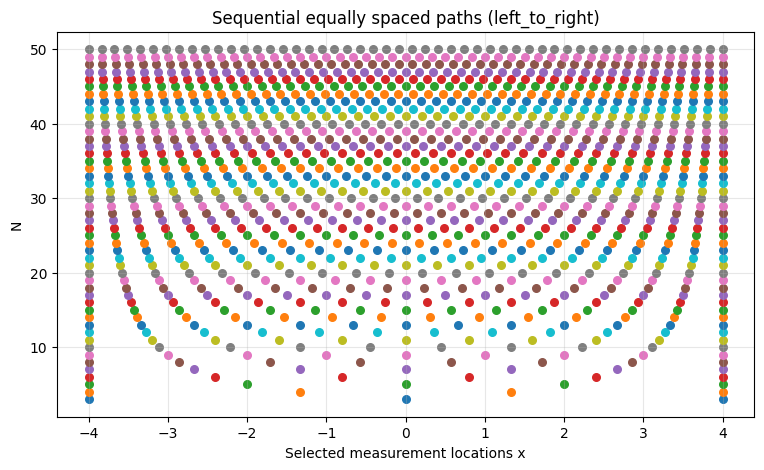

Best feasible N by MSE      : 34  (MSE = 0.00352883)
Best feasible N by mean std : 13  (mean std = 0.0500792)


In [73]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# PARAMETERS
# ============================================================
# Search over number of equally spaced measurement points
N_MIN = 3
N_MAX = 50

# Total campaign budget
TOTAL_BUDGET = B

# Start position before the first measurement
X0 = 0.0

# Linear travel-cost coefficient:
# travel_cost = LAMBDA_TRAVEL * |dx|
LAMBDA_TRAVEL = 3.0

# Path mode for sequential equal sampling
# Options: "left_to_right", "right_to_left", "center_out"
PATH_MODE = "left_to_right"

# GP training settings
TRAINING_ITER = 100
LR = 0.1

# Random seed for simulator reproducibility
RNG_SEED = 123

# Example reconstructions to display
EXAMPLE_NS = [3, 6, 10, 20]

# ============================================================
# ASSUMPTIONS
# ============================================================
# The following objects/functions are assumed to already exist:
#   MeasurementSimulator
#   broad_narrow
#   noise_decay_floor
#   gp_predict
#   x_grid
#   B
#
# If TOTAL_BUDGET is not desired to be B, overwrite TOTAL_BUDGET above.
# ============================================================

def linear_travel_cost(dx, lam=LAMBDA_TRAVEL):
    return lam * np.abs(dx)

def sequential_equal_path(x_min, x_max, N, mode="left_to_right", x0=0.0):
    x_eq = np.linspace(x_min, x_max, N)

    if mode == "left_to_right":
        return x_eq
    elif mode == "right_to_left":
        return x_eq[::-1]
    elif mode == "center_out":
        order = np.argsort(np.abs(x_eq - x0))
        return x_eq[order]
    else:
        raise ValueError(f"Unknown PATH_MODE: {mode}")

def compute_total_travel(x_path, x0=0.0, lam=LAMBDA_TRAVEL):
    x_path = np.asarray(x_path, dtype=float)
    dx = x_path - np.append(x0, x_path[:-1])
    travel_each = linear_travel_cost(dx, lam=lam)
    return float(np.sum(travel_each)), dx, travel_each

def run_equal_spacing_with_cost_for_N(
    N,
    total_budget,
    x_grid,
    gp_predict,
    ground_truth_model,
    noise_model,
    lam=LAMBDA_TRAVEL,
    x0=0.0,
    mode="left_to_right",
    rng_seed=123,
    training_iter=100,
    lr=0.1,
):
    x_min, x_max = float(np.min(x_grid)), float(np.max(x_grid))
    x_path = sequential_equal_path(x_min, x_max, N, mode=mode, x0=x0)

    travel_total, dx, travel_each = compute_total_travel(x_path, x0=x0, lam=lam)
    budget_for_measurements = total_budget - travel_total

    if budget_for_measurements <= 0:
        return {
            "N": N,
            "feasible": False,
            "travel_total": travel_total,
            "budget_for_measurements": budget_for_measurements,
            "t_each": np.nan,
            "x_meas": x_path,
            "dx": dx,
            "travel_each": travel_each,
        }

    t_each = budget_for_measurements / N
    t_meas = np.full(N, t_each)

    meas_sim = MeasurementSimulator(
        ground_truth_model=ground_truth_model,
        noise_model=noise_model,
        rng=rng_seed,
    )

    coords = np.column_stack([x_path, t_meas])
    y_meas = np.asarray(meas_sim.measure(coords), dtype=float)

    mean_pred, std_pred = gp_predict(
        np.asarray(x_path, dtype=float),
        y_meas,
        x_grid,
        training_iter=training_iter,
        lr=lr,
    )

    y_true = np.asarray(ground_truth_model(x_grid), dtype=float)
    mse = float(np.mean((mean_pred - y_true) ** 2))
    mean_std = float(np.mean(std_pred))
    mean_var = float(np.mean(std_pred ** 2))

    return {
        "N": N,
        "feasible": True,
        "travel_total": travel_total,
        "budget_for_measurements": budget_for_measurements,
        "t_each": float(t_each),
        "x_meas": np.asarray(x_path, dtype=float),
        "t_meas": t_meas,
        "y_meas": y_meas,
        "mean_pred": np.asarray(mean_pred, dtype=float),
        "std_pred": np.asarray(std_pred, dtype=float),
        "y_true": y_true,
        "dx": dx,
        "travel_each": travel_each,
        "mse": mse,
        "mean_std": mean_std,
        "mean_var": mean_var,
    }

# ============================================================
# RUN GRID SEARCH
# ============================================================
Ns = np.arange(N_MIN, N_MAX + 1)

results = []
for N in Ns:
    res = run_equal_spacing_with_cost_for_N(
        N=N,
        total_budget=TOTAL_BUDGET,
        x_grid=x_grid,
        gp_predict=gp_predict,
        ground_truth_model=broad_narrow,
        noise_model=noise_decay_floor,
        lam=LAMBDA_TRAVEL,
        x0=X0,
        mode=PATH_MODE,
        rng_seed=RNG_SEED,
        training_iter=TRAINING_ITER,
        lr=LR,
    )
    results.append(res)

feasible_results = [r for r in results if r["feasible"]]
infeasible_results = [r for r in results if not r["feasible"]]

if len(feasible_results) == 0:
    raise RuntimeError("No feasible N values. Increase TOTAL_BUDGET or reduce LAMBDA_TRAVEL.")

Ns_feas = np.array([r["N"] for r in feasible_results], dtype=int)
mse_vals = np.array([r["mse"] for r in feasible_results], dtype=float)
mean_std_vals = np.array([r["mean_std"] for r in feasible_results], dtype=float)
mean_var_vals = np.array([r["mean_var"] for r in feasible_results], dtype=float)
t_each_vals = np.array([r["t_each"] for r in feasible_results], dtype=float)
travel_vals = np.array([r["travel_total"] for r in feasible_results], dtype=float)

print("Feasible N values:", Ns_feas.tolist())
if len(infeasible_results) > 0:
    print("Infeasible N values:", [r["N"] for r in infeasible_results])

# ============================================================
# EXAMPLE RECONSTRUCTIONS
# ============================================================
example_Ns = [n for n in EXAMPLE_NS if n in Ns_feas]

if len(example_Ns) > 0:
    fig, axes = plt.subplots(len(example_Ns), 1, figsize=(9, 3.2 * len(example_Ns)), sharex=True)
    if len(example_Ns) == 1:
        axes = [axes]

    for ax, N_show in zip(axes, example_Ns):
        r = next(rr for rr in feasible_results if rr["N"] == N_show)

        ax.plot(x_grid, r["y_true"], label="Ground truth")
        ax.plot(x_grid, r["mean_pred"], label=f"GP mean (N={N_show})")
        ax.fill_between(
            x_grid,
            r["mean_pred"] - 2 * r["std_pred"],
            r["mean_pred"] + 2 * r["std_pred"],
            alpha=0.25,
            label="±2σ"
        )
        ax.scatter(r["x_meas"], r["y_meas"], s=40, zorder=3, label="Measurements")
        ax.set_ylabel("Signal")
        ax.set_title(
            f"N={N_show}, t_each={r['t_each']:.3f}, travel_total={r['travel_total']:.3f}"
        )
        ax.grid(True, alpha=0.3)
        ax.legend(loc="best")

    axes[-1].set_xlabel("x")
    plt.tight_layout()
    plt.show()

# ============================================================
# METRICS VS N
# ============================================================
fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))

ax[0].plot(Ns_feas, mse_vals, marker='o')
ax[0].set_xlabel("N")
ax[0].set_ylabel("MSE")
ax[0].set_title("MSE vs N")
ax[0].grid(True, alpha=0.3)

ax[1].plot(Ns_feas, mean_std_vals, marker='o', label='Mean predictive std')
ax[1].plot(Ns_feas, mean_var_vals, marker='s', label='Mean predictive variance')
ax[1].set_xlabel("N")
ax[1].set_ylabel("Predictive uncertainty")
ax[1].set_title("Uncertainty vs N")
ax[1].legend()
ax[1].grid(True, alpha=0.3)

ax[2].plot(Ns_feas, t_each_vals, marker='o', label='Dwell time per point')
ax[2].plot(Ns_feas, travel_vals, marker='s', label='Total travel cost')
ax[2].set_xlabel("N")
ax[2].set_ylabel("Cost / time")
ax[2].set_title("Budget split vs N")
ax[2].legend()
ax[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# SELECTED LOCATIONS VS N
# ============================================================
plt.figure(figsize=(9, 5))
for r in feasible_results:
    yrow = np.full_like(r["x_meas"], r["N"], dtype=float)
    plt.scatter(r["x_meas"], yrow, s=30)

plt.xlabel("Selected measurement locations x")
plt.ylabel("N")
plt.title(f"Sequential equally spaced paths ({PATH_MODE})")
plt.grid(True, alpha=0.3)
plt.show()

# ============================================================
# REPORT BEST N
# ============================================================
best_mse_idx = int(np.argmin(mse_vals))
best_unc_idx = int(np.argmin(mean_std_vals))

print(f"Best feasible N by MSE      : {Ns_feas[best_mse_idx]}  (MSE = {mse_vals[best_mse_idx]:.6g})")
print(f"Best feasible N by mean std : {Ns_feas[best_unc_idx]}  (mean std = {mean_std_vals[best_unc_idx]:.6g})")

Now GP exploration with the cost

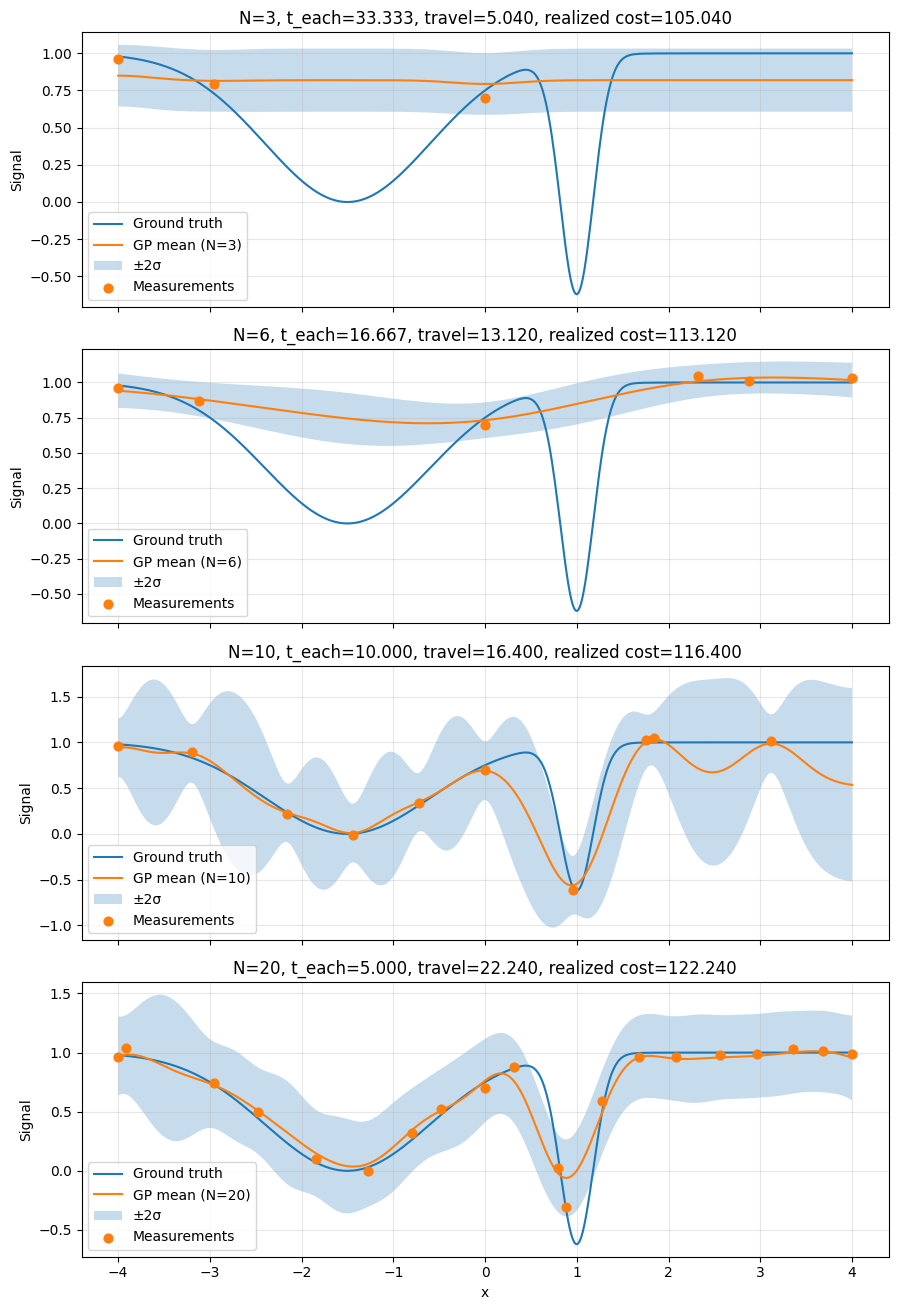

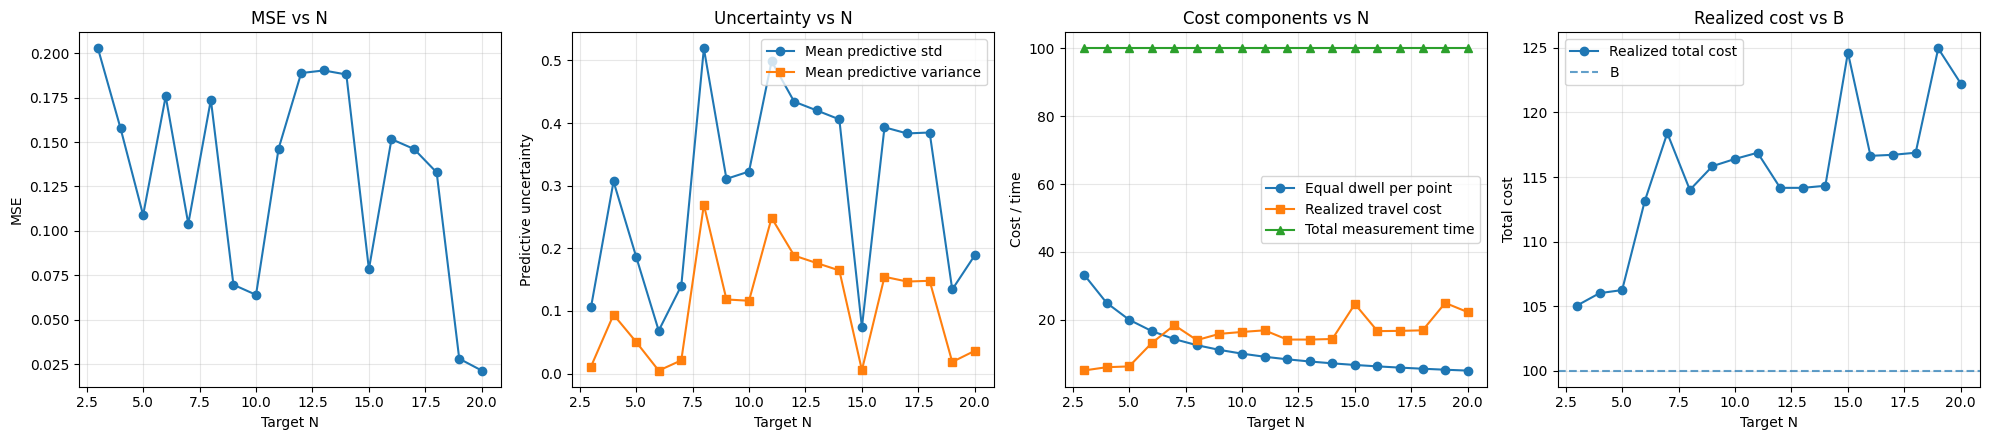

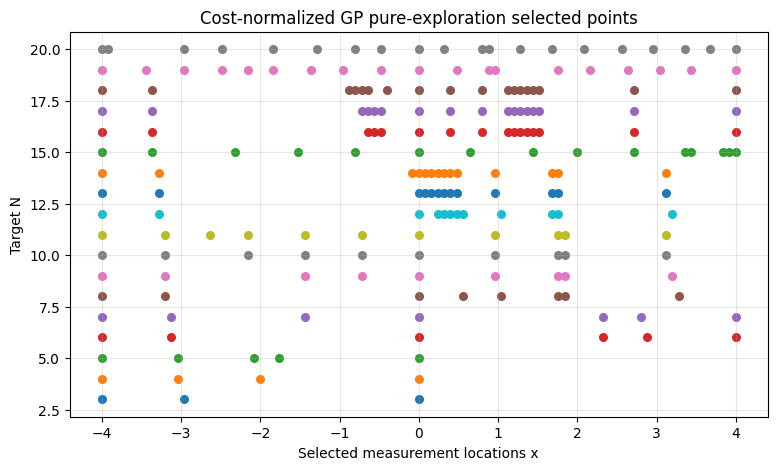

Best N by MSE      : 20  (MSE = 0.0213376)
Best N by mean std : 6  (mean std = 0.0685984)

Realized total cost for each N:
N= 3 | t_each=33.3333 | travel=5.0400 | meas=100.0000 | total=105.0400
N= 4 | t_each=25.0000 | travel=6.0000 | meas=100.0000 | total=106.0000
N= 5 | t_each=20.0000 | travel=6.2400 | meas=100.0000 | total=106.2400
N= 6 | t_each=16.6667 | travel=13.1200 | meas=100.0000 | total=113.1200
N= 7 | t_each=14.2857 | travel=18.4000 | meas=100.0000 | total=118.4000
N= 8 | t_each=12.5000 | travel=14.0000 | meas=100.0000 | total=114.0000
N= 9 | t_each=11.1111 | travel=15.8400 | meas=100.0000 | total=115.8400
N=10 | t_each=10.0000 | travel=16.4000 | meas=100.0000 | total=116.4000
N=11 | t_each=9.0909 | travel=16.8800 | meas=100.0000 | total=116.8800
N=12 | t_each=8.3333 | travel=14.1600 | meas=100.0000 | total=114.1600
N=13 | t_each=7.6923 | travel=14.1600 | meas=100.0000 | total=114.1600
N=14 | t_each=7.1429 | travel=14.3200 | meas=100.0000 | total=114.3200
N=15 | t_each=6.6667

In [75]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# PARAMETERS
# ============================================================
N_MIN = 3
N_MAX = 20

TOTAL_BUDGET = B          # measurement-time budget used to define t_each = B/N
X0 = 0.0                  # starting x position
LAMBDA_TRAVEL = 1.0       # travel cost coefficient: cost = lambda * |dx|

# Acquisition grid for choosing the next point
ACQ_GRID_SIZE = 101

# GP settings
TRAINING_ITER = 100
LR = 0.1

# Simulator seed
RNG_SEED = 123

# Example reconstructions to show
EXAMPLE_NS = [3, 6, 10, 20]

# Exclude exact re-sampling of the same point
EXCLUSION_RADIUS = None

# ------------------------------------------------------------
# IMPORTANT
# ------------------------------------------------------------
# This is the SIMPLE greedy cost-aware acquisition rule:
#
#   score(x) = std(x) / (t_each + lambda * |x - x_current|)
#
# with fixed equal dwell
#
#   t_each = TOTAL_BUDGET / N
#
# It uses cost to choose WHERE to go next.
# It does NOT enforce that the realized total campaign cost
# (measurement time + travel time) stays <= TOTAL_BUDGET.
#
# So this cell is exactly the "divide acquisition by cost" policy.
# It also reports the realized total cost for each N.
# ============================================================

def linear_travel_cost(dx, lam=LAMBDA_TRAVEL):
    return lam * np.abs(dx)

def nearest_value(arr, x):
    arr = np.asarray(arr, dtype=float)
    return float(arr[np.argmin(np.abs(arr - x))])

def choose_second_seed(candidate_x, x_first, exclusion_radius):
    """Pick a second seed far from the first one to initialize the GP."""
    candidate_x = np.asarray(candidate_x, dtype=float)
    mask = np.abs(candidate_x - x_first) > exclusion_radius
    if not np.any(mask):
        return None
    idx = np.argmax(np.abs(candidate_x[mask] - x_first))
    return float(candidate_x[mask][idx])

def choose_next_x_cost_ratio(
    x_obs,
    y_obs,
    x_current,
    t_each,
    candidate_x,
    gp_predict,
    training_iter,
    lr,
    lam=LAMBDA_TRAVEL,
    exclusion_radius=None,
):
    """
    Greedy cost-aware pure exploration:
        score(x) = std(x) / (t_each + lam * |x - x_current|)
    """
    x_obs = np.asarray(x_obs, dtype=float)
    y_obs = np.asarray(y_obs, dtype=float)
    candidate_x = np.asarray(candidate_x, dtype=float)

    # GP predictive std on candidate grid
    _, std_cand = gp_predict(
        x_obs, y_obs, candidate_x,
        training_iter=training_iter,
        lr=lr,
    )
    std_cand = np.asarray(std_cand, dtype=float)

    if exclusion_radius is None:
        if len(candidate_x) > 1:
            exclusion_radius = 0.5 * np.min(np.diff(np.unique(candidate_x)))
        else:
            exclusion_radius = 1e-12

    # Exclude already visited points
    visited_mask = np.zeros_like(candidate_x, dtype=bool)
    for xo in x_obs:
        visited_mask |= np.abs(candidate_x - xo) <= exclusion_radius

    move_costs = linear_travel_cost(candidate_x - x_current, lam=lam)
    total_action_costs = t_each + move_costs

    scores = np.full_like(candidate_x, -np.inf, dtype=float)
    valid_mask = ~visited_mask
    scores[valid_mask] = std_cand[valid_mask] / np.maximum(total_action_costs[valid_mask], 1e-12)

    idx = int(np.argmax(scores))
    if not np.isfinite(scores[idx]):
        return None

    return {
        "x_next": float(candidate_x[idx]),
        "std_next": float(std_cand[idx]),
        "move_cost": float(move_costs[idx]),
        "action_cost": float(total_action_costs[idx]),
        "score": float(scores[idx]),
    }

def run_cost_ratio_exploration_for_N(
    N,
    total_budget,
    x0,
    x_grid,
    gp_predict,
    ground_truth_model,
    noise_model,
    acq_grid_size=101,
    training_iter=100,
    lr=0.1,
    rng_seed=123,
    lam=LAMBDA_TRAVEL,
    exclusion_radius=None,
):
    """
    For a fixed target N:
      - use equal dwell time t_each = total_budget / N
      - choose points sequentially with score = std / cost
      - report realized total cost = measurement time + travel
    """
    t_each = float(total_budget / N)

    candidate_x = np.linspace(float(np.min(x_grid)), float(np.max(x_grid)), acq_grid_size)

    if exclusion_radius is None:
        if len(candidate_x) > 1:
            exclusion_radius = 0.5 * np.min(np.diff(candidate_x))
        else:
            exclusion_radius = 1e-12

    meas_sim = MeasurementSimulator(
        ground_truth_model=ground_truth_model,
        noise_model=noise_model,
        rng=rng_seed,
    )

    x_obs, y_obs, t_obs = [], [], []
    history = []

    x_current = float(np.clip(x0, np.min(candidate_x), np.max(candidate_x)))

    # --------------------------------------------------------
    # Seed 1: nearest candidate to x0
    # --------------------------------------------------------
    x_first = nearest_value(candidate_x, x_current)
    move_cost_1 = float(linear_travel_cost(x_first - x_current, lam=lam))
    y_first = float(meas_sim.measure(np.array([[x_first, t_each]]))[0])

    x_obs.append(x_first)
    y_obs.append(y_first)
    t_obs.append(t_each)
    x_current = x_first

    history.append({
        "step": 1,
        "x": float(x_first),
        "y": float(y_first),
        "t": float(t_each),
        "move_cost": float(move_cost_1),
        "action_cost": float(move_cost_1 + t_each),
        "score": np.nan,
        "type": "seed_1",
    })

    # --------------------------------------------------------
    # Seed 2: farthest point from the first one
    # --------------------------------------------------------
    if N >= 2:
        x_second = choose_second_seed(candidate_x, x_first, exclusion_radius)
        if x_second is not None:
            move_cost_2 = float(linear_travel_cost(x_second - x_current, lam=lam))
            y_second = float(meas_sim.measure(np.array([[x_second, t_each]]))[0])

            x_obs.append(x_second)
            y_obs.append(y_second)
            t_obs.append(t_each)
            x_current = x_second

            history.append({
                "step": 2,
                "x": float(x_second),
                "y": float(y_second),
                "t": float(t_each),
                "move_cost": float(move_cost_2),
                "action_cost": float(move_cost_2 + t_each),
                "score": np.nan,
                "type": "seed_2",
            })

    # --------------------------------------------------------
    # Sequential cost-aware pure exploration
    # --------------------------------------------------------
    while len(x_obs) < N:
        nxt = choose_next_x_cost_ratio(
            x_obs=x_obs,
            y_obs=y_obs,
            x_current=x_current,
            t_each=t_each,
            candidate_x=candidate_x,
            gp_predict=gp_predict,
            training_iter=training_iter,
            lr=lr,
            lam=lam,
            exclusion_radius=exclusion_radius,
        )

        if nxt is None:
            break

        x_next = nxt["x_next"]
        y_next = float(meas_sim.measure(np.array([[x_next, t_each]]))[0])

        x_obs.append(x_next)
        y_obs.append(y_next)
        t_obs.append(t_each)
        x_current = x_next

        history.append({
            "step": len(x_obs),
            "x": float(x_next),
            "y": float(y_next),
            "t": float(t_each),
            "move_cost": float(nxt["move_cost"]),
            "action_cost": float(nxt["action_cost"]),
            "score": float(nxt["score"]),
            "type": "adaptive",
        })

    x_obs = np.asarray(x_obs, dtype=float)
    y_obs = np.asarray(y_obs, dtype=float)
    t_obs = np.asarray(t_obs, dtype=float)

    mean_pred, std_pred = gp_predict(
        x_obs, y_obs, x_grid,
        training_iter=training_iter,
        lr=lr,
    )

    y_true = np.asarray(ground_truth_model(x_grid), dtype=float)

    total_travel = float(np.sum([h["move_cost"] for h in history]))
    total_measurement = float(np.sum(t_obs))
    total_cost = float(total_travel + total_measurement)

    mse = float(np.mean((np.asarray(mean_pred) - y_true) ** 2))
    mean_std = float(np.mean(np.asarray(std_pred)))
    mean_var = float(np.mean(np.asarray(std_pred) ** 2))

    return {
        "N": int(N),
        "N_done": int(len(x_obs)),
        "t_each": float(t_each),
        "x_meas": x_obs,
        "y_meas": y_obs,
        "t_meas": t_obs,
        "mean_pred": np.asarray(mean_pred, dtype=float),
        "std_pred": np.asarray(std_pred, dtype=float),
        "y_true": y_true,
        "mse": mse,
        "mean_std": mean_std,
        "mean_var": mean_var,
        "total_travel": total_travel,
        "total_measurement": total_measurement,
        "total_cost": total_cost,
        "history": history,
    }

# ============================================================
# RUN SWEEP OVER N
# ============================================================
results = []
for N in range(N_MIN, N_MAX + 1):
    res = run_cost_ratio_exploration_for_N(
        N=N,
        total_budget=TOTAL_BUDGET,
        x0=X0,
        x_grid=x_grid,
        gp_predict=gp_predict,
        ground_truth_model=broad_narrow,
        noise_model=noise_decay_floor,
        acq_grid_size=ACQ_GRID_SIZE,
        training_iter=TRAINING_ITER,
        lr=LR,
        rng_seed=RNG_SEED,
        lam=LAMBDA_TRAVEL,
        exclusion_radius=EXCLUSION_RADIUS,
    )
    results.append(res)

Ns = np.array([r["N"] for r in results], dtype=int)
N_done_vals = np.array([r["N_done"] for r in results], dtype=int)
mse_vals = np.array([r["mse"] for r in results], dtype=float)
mean_std_vals = np.array([r["mean_std"] for r in results], dtype=float)
mean_var_vals = np.array([r["mean_var"] for r in results], dtype=float)
t_each_vals = np.array([r["t_each"] for r in results], dtype=float)
travel_vals = np.array([r["total_travel"] for r in results], dtype=float)
measurement_vals = np.array([r["total_measurement"] for r in results], dtype=float)
total_cost_vals = np.array([r["total_cost"] for r in results], dtype=float)

# ============================================================
# EXAMPLE RECONSTRUCTIONS
# ============================================================
example_Ns = [n for n in EXAMPLE_NS if n in Ns]

fig, axes = plt.subplots(len(example_Ns), 1, figsize=(9, 3.3 * len(example_Ns)), sharex=True)
if len(example_Ns) == 1:
    axes = [axes]

for ax, N_show in zip(axes, example_Ns):
    r = next(rr for rr in results if rr["N"] == N_show)

    ax.plot(x_grid, r["y_true"], label="Ground truth")
    ax.plot(x_grid, r["mean_pred"], label=f"GP mean (N={N_show})")
    ax.fill_between(
        x_grid,
        r["mean_pred"] - 2.0 * r["std_pred"],
        r["mean_pred"] + 2.0 * r["std_pred"],
        alpha=0.25,
        label="±2σ",
    )
    ax.scatter(r["x_meas"], r["y_meas"], s=40, zorder=3, label="Measurements")
    ax.set_ylabel("Signal")
    ax.set_title(
        f"N={N_show}, t_each={r['t_each']:.3f}, travel={r['total_travel']:.3f}, realized cost={r['total_cost']:.3f}"
    )
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")

axes[-1].set_xlabel("x")
plt.tight_layout()
plt.show()

# ============================================================
# METRICS VS N
# ============================================================
fig, ax = plt.subplots(1, 4, figsize=(20, 4.5))

ax[0].plot(Ns, mse_vals, marker='o')
ax[0].set_xlabel("Target N")
ax[0].set_ylabel("MSE")
ax[0].set_title("MSE vs N")
ax[0].grid(True, alpha=0.3)

ax[1].plot(Ns, mean_std_vals, marker='o', label='Mean predictive std')
ax[1].plot(Ns, mean_var_vals, marker='s', label='Mean predictive variance')
ax[1].set_xlabel("Target N")
ax[1].set_ylabel("Predictive uncertainty")
ax[1].set_title("Uncertainty vs N")
ax[1].legend()
ax[1].grid(True, alpha=0.3)

ax[2].plot(Ns, t_each_vals, marker='o', label='Equal dwell per point')
ax[2].plot(Ns, travel_vals, marker='s', label='Realized travel cost')
ax[2].plot(Ns, measurement_vals, marker='^', label='Total measurement time')
ax[2].set_xlabel("Target N")
ax[2].set_ylabel("Cost / time")
ax[2].set_title("Cost components vs N")
ax[2].legend()
ax[2].grid(True, alpha=0.3)

ax[3].plot(Ns, total_cost_vals, marker='o', label='Realized total cost')
ax[3].axhline(TOTAL_BUDGET, linestyle='--', alpha=0.7, label='B')
ax[3].set_xlabel("Target N")
ax[3].set_ylabel("Total cost")
ax[3].set_title("Realized cost vs B")
ax[3].legend()
ax[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# SELECTED LOCATIONS VS N
# ============================================================
plt.figure(figsize=(9, 5))
for r in results:
    yrow = np.full_like(r["x_meas"], r["N"], dtype=float)
    plt.scatter(r["x_meas"], yrow, s=30)

plt.xlabel("Selected measurement locations x")
plt.ylabel("Target N")
plt.title("Cost-normalized GP pure-exploration selected points")
plt.grid(True, alpha=0.3)
plt.show()

# ============================================================
# REPORT BEST N
# ============================================================
best_mse_idx = int(np.argmin(mse_vals))
best_unc_idx = int(np.argmin(mean_std_vals))

print(f"Best N by MSE      : {Ns[best_mse_idx]}  (MSE = {mse_vals[best_mse_idx]:.6g})")
print(f"Best N by mean std : {Ns[best_unc_idx]}  (mean std = {mean_std_vals[best_unc_idx]:.6g})")

print("\nRealized total cost for each N:")
for r in results:
    print(
        f"N={r['N']:2d} | t_each={r['t_each']:.4f} | "
        f"travel={r['total_travel']:.4f} | meas={r['total_measurement']:.4f} | "
        f"total={r['total_cost']:.4f}"
    )

# Dynamic programming

Optimal DP objective value: 4.751870
Number of planned measurements : 5
Total travel cost             : 36.000000
Total measurement time        : 60.000000
Total realized cost           : 96.000000
Unused budget                 : 4.000000
Final reconstruction MSE      : 0.0846917

Planned campaign:
step= 1 | x_from=+0.000 -> x_to=+0.000 | t=10.0 | move=0.000 | cost=10.000 | reward=1.003870 | budget_left=90.000
step= 2 | x_from=+0.000 -> x_to=-1.333 | t=15.0 | move=4.000 | cost=19.000 | reward=0.928293 | budget_left=71.000
step= 3 | x_from=-1.333 -> x_to=-4.000 | t=10.0 | move=8.000 | cost=18.000 | reward=0.947904 | budget_left=53.000
step= 4 | x_from=-4.000 -> x_to=+2.667 | t=10.0 | move=20.000 | cost=30.000 | reward=1.003430 | budget_left=23.000
step= 5 | x_from=+2.667 -> x_to=+4.000 | t=15.0 | move=4.000 | cost=19.000 | reward=0.868374 | budget_left=4.000


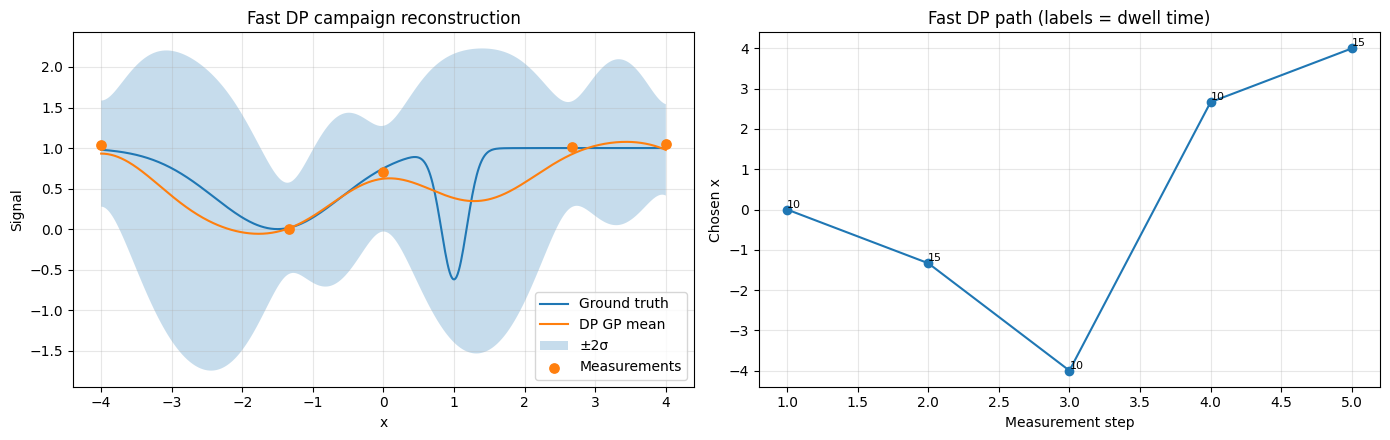

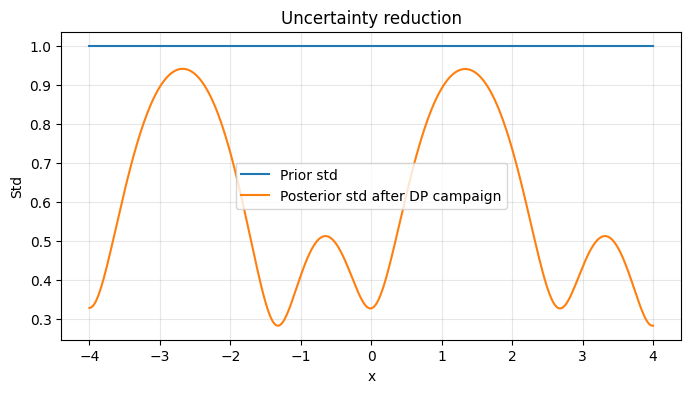

In [87]:
import numpy as np
import matplotlib.pyplot as plt
from functools import lru_cache

# ============================================================
# FAST PARAMETERS
# ============================================================
TOTAL_BUDGET = B
X0 = 0.0
LAMBDA_TRAVEL = 3.0

# Coarser DP = much faster
DP_CANDIDATE_POINTS = 7                 # was 9
DWELL_CHOICES = np.array([10.0, 15, 20.0])  # fewer actions
BUDGET_BIN = 10.0                       # coarser budget discretization
RHO_ROUND_DECIMALS = 2                  # more state merging

# GP model used by planner and reconstruction
KERNEL_VARIANCE = 1.0
KERNEL_LENGTHSCALE = 0.8
JITTER = 1e-8

# Assumed noise model for planner / reconstruction
# var(t) = NOISE_A / t^NOISE_ALPHA + NOISE_FLOOR
NOISE_A = 1.0
NOISE_ALPHA = 1.0
NOISE_FLOOR = 0.02

SIMULATOR_SEED = 123
GROUND_TRUTH_MODEL = broad_narrow
NOISE_MODEL = noise_decay_floor

SHOW_TOP_STEPS = 50

# ============================================================
# ASSUMPTIONS
# ============================================================
# Expected to already exist in memory:
#   MeasurementSimulator
#   broad_narrow
#   noise_decay_floor
#   x_grid
# ============================================================

# ============================================================
# HELPERS
# ============================================================
def rbf_kernel(x1, x2, variance=1.0, lengthscale=1.0):
    x1 = np.atleast_1d(x1).astype(float)[:, None]
    x2 = np.atleast_1d(x2).astype(float)[None, :]
    d2 = (x1 - x2) ** 2
    return variance * np.exp(-0.5 * d2 / (lengthscale ** 2))

def noise_var_from_t(t):
    t = np.asarray(t, dtype=float)
    return NOISE_A / np.maximum(t, 1e-12) ** NOISE_ALPHA + NOISE_FLOOR

def gp_posterior_predictive(x_train, y_train, noise_var_train, x_test,
                            variance=1.0, lengthscale=1.0, jitter=1e-8):
    x_train = np.asarray(x_train, dtype=float)
    y_train = np.asarray(y_train, dtype=float)
    noise_var_train = np.asarray(noise_var_train, dtype=float)
    x_test = np.asarray(x_test, dtype=float)

    if len(x_train) == 0:
        K_ss = rbf_kernel(x_test, x_test, variance, lengthscale)
        std = np.sqrt(np.clip(np.diag(K_ss), 0.0, None))
        mean = np.zeros_like(x_test)
        return mean, std

    K_tt = rbf_kernel(x_train, x_train, variance, lengthscale)
    K_tt = K_tt + np.diag(noise_var_train) + jitter * np.eye(len(x_train))
    K_ts = rbf_kernel(x_train, x_test, variance, lengthscale)
    K_ss = rbf_kernel(x_test, x_test, variance, lengthscale)

    alpha = np.linalg.solve(K_tt, y_train)
    mean = K_ts.T @ alpha

    v = np.linalg.solve(K_tt, K_ts)
    cov = K_ss - K_ts.T @ v
    std = np.sqrt(np.clip(np.diag(cov), 0.0, None))
    return mean, std

def budget_to_bin(b):
    return max(int(np.floor(float(b) / BUDGET_BIN + 1e-12)), 0)

def bin_to_budget(bbin):
    return float(bbin) * BUDGET_BIN

def round_rho_key(rho):
    return tuple(np.round(np.asarray(rho, dtype=float), RHO_ROUND_DECIMALS))

# ============================================================
# PRECOMPUTE DP STRUCTURES
# ============================================================
candidate_x = np.linspace(float(np.min(x_grid)), float(np.max(x_grid)), DP_CANDIDATE_POINTS)
positions = np.concatenate([[X0], candidate_x])   # positions[0] is start
M = len(candidate_x)

K_prior = rbf_kernel(candidate_x, candidate_x,
                     variance=KERNEL_VARIANCE,
                     lengthscale=KERNEL_LENGTHSCALE)
K_prior = K_prior + JITTER * np.eye(M)
K_inv = np.linalg.inv(K_prior)

# Precompute all travel costs between current position index and next position index
travel_mat = LAMBDA_TRAVEL * np.abs(positions[:, None] - positions[None, :])

# Precompute dwell precisions
dwell_precisions = 1.0 / noise_var_from_t(DWELL_CHOICES)
min_dwell = float(np.min(DWELL_CHOICES))

# ============================================================
# CACHED UTILITY
# ============================================================
@lru_cache(None)
def utility_from_rho_key(rho_key):
    """
    Option A:
        U = -trace(Sigma)
    where Sigma = (K^{-1} + diag(rho))^{-1}
    """
    rho = np.asarray(rho_key, dtype=float)
    A = K_inv + np.diag(rho)
    Sigma = np.linalg.inv(A)
    return -float(np.trace(Sigma))

policy = {}

@lru_cache(None)
def V(rho_key, cur_pos_idx, budget_bin):
    """
    State:
        rho_key      : rounded precision vector on candidate grid
        cur_pos_idx  : index in positions (0=start, 1..M=candidates)
        budget_bin   : discretized remaining budget
    """
    budget = bin_to_budget(budget_bin)
    if budget < min_dwell - 1e-12:
        policy[(rho_key, cur_pos_idx, budget_bin)] = None
        return 0.0

    U_now = utility_from_rho_key(rho_key)
    best_value = 0.0
    best_action = None

    for next_pos_idx in range(1, M + 1):
        move = float(travel_mat[cur_pos_idx, next_pos_idx])

        for k, t in enumerate(DWELL_CHOICES):
            cost = float(t + move)
            if cost > budget + 1e-12:
                continue

            rho_new = np.array(rho_key, dtype=float)
            rho_new[next_pos_idx - 1] += float(dwell_precisions[k])
            rho_new_key = round_rho_key(rho_new)

            U_new = utility_from_rho_key(rho_new_key)
            immediate_reward = U_new - U_now

            next_budget_bin = budget_to_bin(budget - cost)
            total_value = immediate_reward + V(rho_new_key, next_pos_idx, next_budget_bin)

            if total_value > best_value + 1e-12:
                best_value = total_value
                best_action = (next_pos_idx, float(t), move, cost, immediate_reward)

    policy[(rho_key, cur_pos_idx, budget_bin)] = best_action
    return best_value

# ============================================================
# SOLVE DP
# ============================================================
rho0_key = round_rho_key(np.zeros(M))
budget_bin0 = budget_to_bin(TOTAL_BUDGET)
best_total_value = V(rho0_key, 0, budget_bin0)
print(f"Optimal DP objective value: {best_total_value:.6f}")

# ============================================================
# EXTRACT PLAN
# ============================================================
plan = []
rho_key = rho0_key
cur_pos_idx = 0
budget_actual = float(TOTAL_BUDGET)

while True:
    state = (rho_key, cur_pos_idx, budget_to_bin(budget_actual))
    if state not in policy:
        _ = V(*state)
    action = policy.get(state, None)

    if action is None:
        break

    next_pos_idx, t, move, cost, reward = action
    if cost > budget_actual + 1e-12:
        break

    plan.append({
        "step": len(plan) + 1,
        "x_from": float(positions[cur_pos_idx]),
        "x_to": float(positions[next_pos_idx]),
        "t": float(t),
        "move_cost": float(move),
        "action_cost": float(cost),
        "reward": float(reward),
        "budget_left_after": float(budget_actual - cost),
    })

    rho_new = np.array(rho_key, dtype=float)
    dwell_idx = int(np.argmin(np.abs(DWELL_CHOICES - t)))
    rho_new[next_pos_idx - 1] += float(dwell_precisions[dwell_idx])
    rho_key = round_rho_key(rho_new)

    cur_pos_idx = next_pos_idx
    budget_actual -= cost

if len(plan) == 0:
    raise RuntimeError("DP returned an empty plan. Increase budget or reduce costs.")

# ============================================================
# EXECUTE PLAN ON SIMULATOR
# ============================================================
meas_sim = MeasurementSimulator(
    ground_truth_model=GROUND_TRUTH_MODEL,
    noise_model=NOISE_MODEL,
    rng=SIMULATOR_SEED,
)

x_meas = np.array([p["x_to"] for p in plan], dtype=float)
t_meas = np.array([p["t"] for p in plan], dtype=float)
coords = np.column_stack([x_meas, t_meas])
y_meas = np.asarray(meas_sim.measure(coords), dtype=float)

noise_vars = noise_var_from_t(t_meas)
mean_pred, std_pred = gp_posterior_predictive(
    x_train=x_meas,
    y_train=y_meas,
    noise_var_train=noise_vars,
    x_test=x_grid,
    variance=KERNEL_VARIANCE,
    lengthscale=KERNEL_LENGTHSCALE,
    jitter=JITTER,
)

y_true = np.asarray(GROUND_TRUTH_MODEL(x_grid), dtype=float)
mse = float(np.mean((mean_pred - y_true) ** 2))

total_travel = float(np.sum([p["move_cost"] for p in plan]))
total_measurement = float(np.sum(t_meas))
total_cost = total_travel + total_measurement

print(f"Number of planned measurements : {len(plan)}")
print(f"Total travel cost             : {total_travel:.6f}")
print(f"Total measurement time        : {total_measurement:.6f}")
print(f"Total realized cost           : {total_cost:.6f}")
print(f"Unused budget                 : {TOTAL_BUDGET - total_cost:.6f}")
print(f"Final reconstruction MSE      : {mse:.6g}")

print("\nPlanned campaign:")
for p in plan[:SHOW_TOP_STEPS]:
    print(
        f"step={p['step']:2d} | x_from={p['x_from']:+.3f} -> x_to={p['x_to']:+.3f} | "
        f"t={p['t']:.1f} | move={p['move_cost']:.3f} | cost={p['action_cost']:.3f} | "
        f"reward={p['reward']:.6f} | budget_left={p['budget_left_after']:.3f}"
    )
if len(plan) > SHOW_TOP_STEPS:
    print(f"... ({len(plan) - SHOW_TOP_STEPS} more steps)")

# ============================================================
# PLOTS
# ============================================================
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))

ax[0].plot(x_grid, y_true, label="Ground truth")
ax[0].plot(x_grid, mean_pred, label="DP GP mean")
ax[0].fill_between(
    x_grid,
    mean_pred - 2.0 * std_pred,
    mean_pred + 2.0 * std_pred,
    alpha=0.25,
    label="±2σ",
)
ax[0].scatter(x_meas, y_meas, s=45, zorder=3, label="Measurements")
ax[0].set_xlabel("x")
ax[0].set_ylabel("Signal")
ax[0].set_title("Fast DP campaign reconstruction")
ax[0].grid(True, alpha=0.3)
ax[0].legend(loc="best")

steps = np.arange(1, len(plan) + 1)
ax[1].plot(steps, x_meas, marker='o')
for s, x, t in zip(steps, x_meas, t_meas):
    ax[1].text(s, x, f"{t:.0f}", fontsize=8, ha="left", va="bottom")
ax[1].set_xlabel("Measurement step")
ax[1].set_ylabel("Chosen x")
ax[1].set_title("Fast DP path (labels = dwell time)")
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
prior_std = np.sqrt(np.clip(np.diag(rbf_kernel(
    x_grid, x_grid,
    variance=KERNEL_VARIANCE,
    lengthscale=KERNEL_LENGTHSCALE
)), 0.0, None))
plt.plot(x_grid, prior_std, label="Prior std")
plt.plot(x_grid, std_pred, label="Posterior std after DP campaign")
plt.xlabel("x")
plt.ylabel("Std")
plt.title("Uncertainty reduction")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

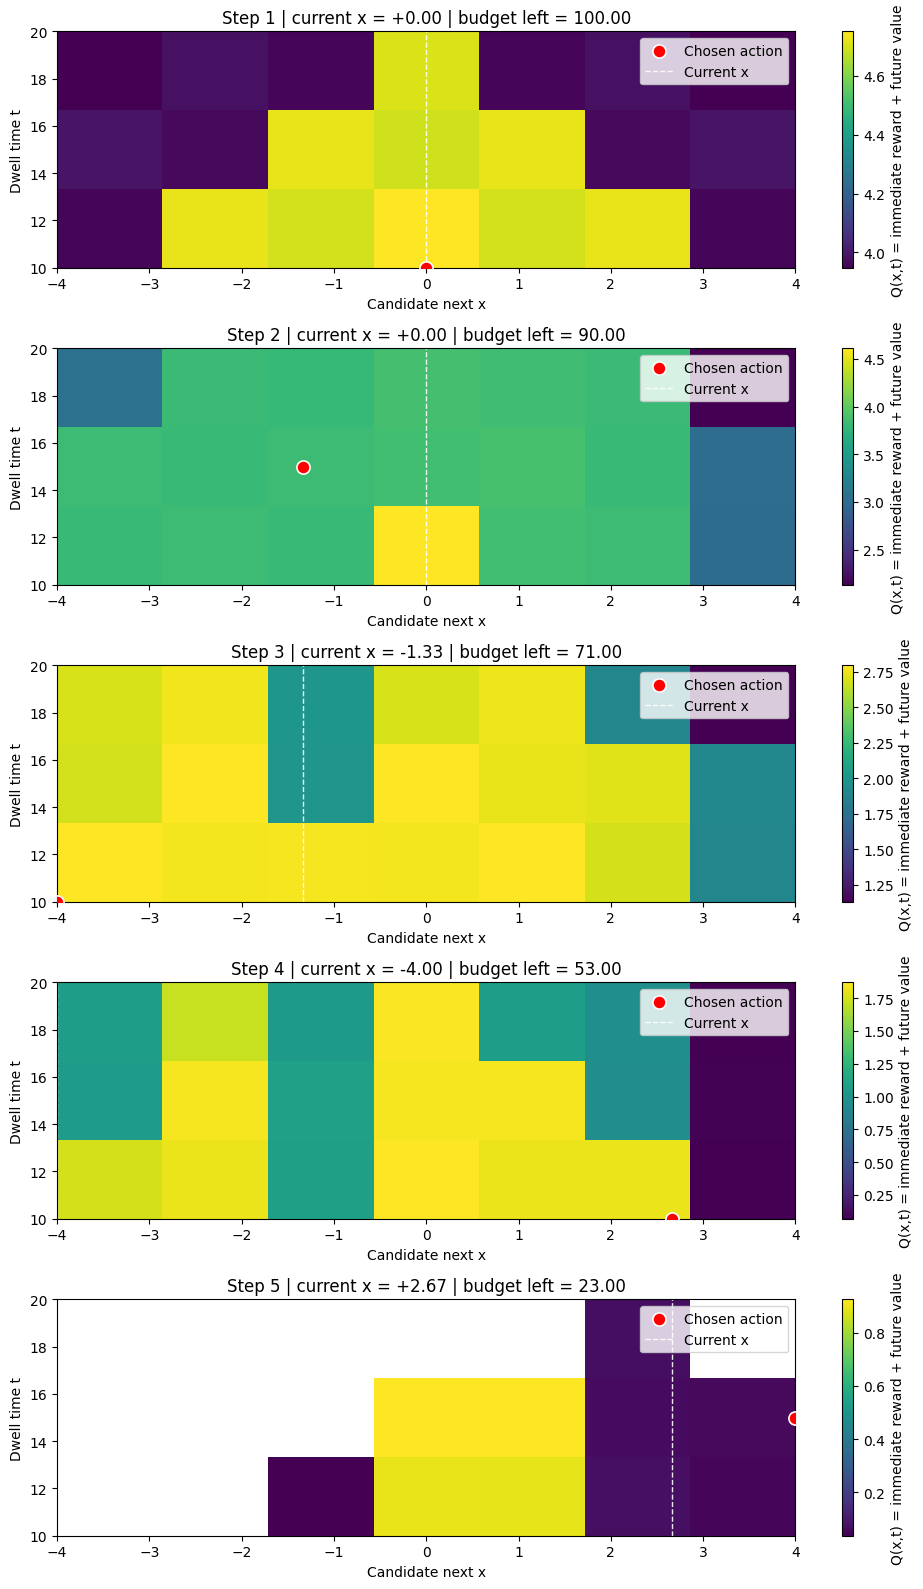

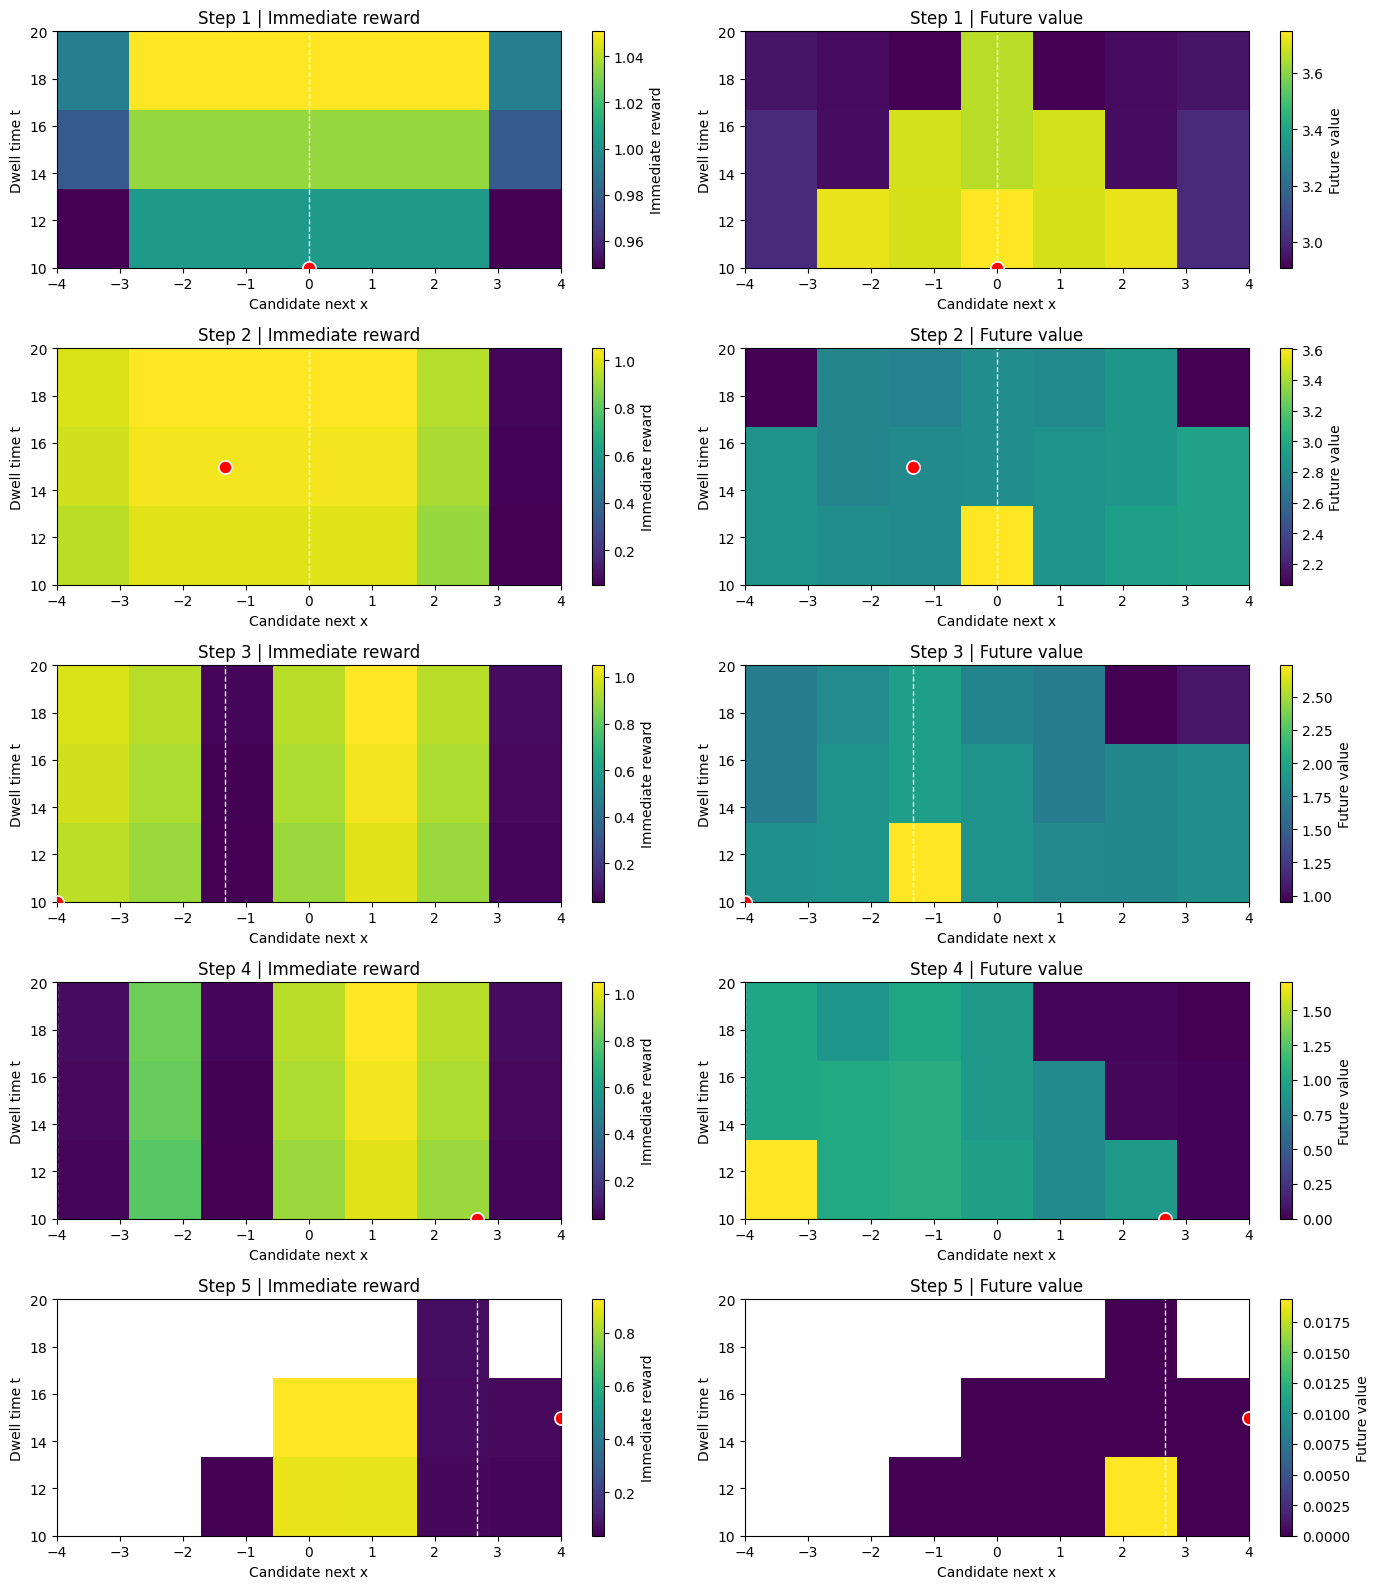

In [88]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# PARAMETERS
# ============================================================
# Which campaign steps to visualize.
# If None, choose a few evenly spaced steps automatically.
STEPS_TO_PLOT = None

# Maximum number of panels if STEPS_TO_PLOT is None
MAX_PANELS = 10

# Colormap for Q(x,t)
CMAP = "viridis"

# ============================================================
# ASSUMPTIONS
# ============================================================
# This cell assumes you already ran the DP cell and therefore
# these objects exist in memory:
#
#   plan
#   positions
#   candidate_x
#   DWELL_CHOICES
#   TOTAL_BUDGET
#   utility_from_rho_key
#   V
#   budget_to_bin
#   round_rho_key
#   noise_var_from_t
#   travel_mat   (or at least positions and LAMBDA_TRAVEL)
#
# plan is the executed optimal plan from the DP cell.
# ============================================================

# ---------- small helper ----------
def precision_from_t_local(t):
    return 1.0 / noise_var_from_t(t)

# Travel matrix fallback if not present
if "travel_mat" not in globals():
    travel_mat = LAMBDA_TRAVEL * np.abs(positions[:, None] - positions[None, :])

# ---------- reconstruct DP state before each executed step ----------
M = len(candidate_x)
rho_key = round_rho_key(np.zeros(M))
cur_pos_idx = 0
budget_actual = float(TOTAL_BUDGET)

state_history = []
for p in plan:
    state_history.append({
        "step": p["step"],
        "rho_key": rho_key,
        "cur_pos_idx": cur_pos_idx,
        "budget_actual": budget_actual,
        "chosen_x": float(p["x_to"]),
        "chosen_t": float(p["t"]),
    })

    # advance to next state using executed action
    next_pos_idx = int(np.argmin(np.abs(positions - p["x_to"])))
    rho_new = np.array(rho_key, dtype=float)
    rho_new[next_pos_idx - 1] += float(precision_from_t_local(p["t"]))
    rho_key = round_rho_key(rho_new)
    cur_pos_idx = next_pos_idx
    budget_actual -= float(p["action_cost"])

if len(state_history) == 0:
    raise RuntimeError("No plan/state history found. Run the DP campaign cell first.")

# ---------- choose which steps to plot ----------
all_steps = [s["step"] for s in state_history]
if STEPS_TO_PLOT is None:
    if len(all_steps) <= MAX_PANELS:
        steps_to_plot = all_steps
    else:
        idx = np.linspace(0, len(all_steps) - 1, MAX_PANELS).round().astype(int)
        steps_to_plot = [all_steps[i] for i in idx]
else:
    steps_to_plot = [s for s in STEPS_TO_PLOT if s in all_steps]

selected_states = [s for s in state_history if s["step"] in steps_to_plot]

# ---------- compute Q tables ----------
def compute_q_tables(rho_key, cur_pos_idx, budget_actual):
    """
    Returns:
      Q_total      shape (n_t, M)
      Q_immediate  shape (n_t, M)
      Q_future     shape (n_t, M)
    for candidate_x (columns) and DWELL_CHOICES (rows).
    """
    rho = np.array(rho_key, dtype=float)
    U_now = utility_from_rho_key(rho_key)

    n_t = len(DWELL_CHOICES)
    Q_total = np.full((n_t, M), np.nan, dtype=float)
    Q_immediate = np.full((n_t, M), np.nan, dtype=float)
    Q_future = np.full((n_t, M), np.nan, dtype=float)

    for j in range(M):  # candidate point index in candidate_x
        next_pos_idx = j + 1  # because positions[0] is start
        move = float(travel_mat[cur_pos_idx, next_pos_idx])

        for k, t in enumerate(DWELL_CHOICES):
            cost = float(t + move)
            if cost > budget_actual + 1e-12:
                continue

            rho_new = rho.copy()
            rho_new[j] += float(precision_from_t_local(t))
            rho_new_key = round_rho_key(rho_new)

            U_new = utility_from_rho_key(rho_new_key)
            immediate = U_new - U_now
            future = V(rho_new_key, next_pos_idx, budget_to_bin(budget_actual - cost))
            total = immediate + future

            Q_immediate[k, j] = immediate
            Q_future[k, j] = future
            Q_total[k, j] = total

    return Q_total, Q_immediate, Q_future

q_results = []
for s in selected_states:
    Q_total, Q_immediate, Q_future = compute_q_tables(
        rho_key=s["rho_key"],
        cur_pos_idx=s["cur_pos_idx"],
        budget_actual=s["budget_actual"],
    )
    q_results.append({
        "step": s["step"],
        "budget_actual": s["budget_actual"],
        "cur_x": float(positions[s["cur_pos_idx"]]),
        "chosen_x": s["chosen_x"],
        "chosen_t": s["chosen_t"],
        "Q_total": Q_total,
        "Q_immediate": Q_immediate,
        "Q_future": Q_future,
    })

# ---------- plot total Q(x,t) heatmaps ----------
n_panels = len(q_results)
fig, axes = plt.subplots(n_panels, 1, figsize=(10, 3.2 * n_panels), squeeze=False)

for ax, qr in zip(axes[:, 0], q_results):
    Q = qr["Q_total"]

    # imshow extent: x horizontally, dwell vertically
    im = ax.imshow(
        Q,
        origin="lower",
        aspect="auto",
        cmap=CMAP,
        extent=[candidate_x.min(), candidate_x.max(), DWELL_CHOICES.min(), DWELL_CHOICES.max()],
    )

    # mark chosen action
    ax.scatter(
        [qr["chosen_x"]],
        [qr["chosen_t"]],
        s=90,
        c="red",
        edgecolors="white",
        linewidths=1.2,
        label="Chosen action",
        zorder=3,
    )

    # mark current position
    ax.axvline(qr["cur_x"], color="white", linestyle="--", linewidth=1.0, alpha=0.9, label="Current x")

    ax.set_title(
        f"Step {qr['step']} | current x = {qr['cur_x']:+.2f} | budget left = {qr['budget_actual']:.2f}"
    )
    ax.set_xlabel("Candidate next x")
    ax.set_ylabel("Dwell time t")
    ax.legend(loc="upper right")

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Q(x,t) = immediate reward + future value")

plt.tight_layout()
plt.show()

# ---------- optional decomposition: immediate reward vs future value ----------
fig, axes = plt.subplots(n_panels, 2, figsize=(14, 3.2 * n_panels), squeeze=False)

for row, qr in enumerate(q_results):
    for col, (title, Q) in enumerate([
        ("Immediate reward", qr["Q_immediate"]),
        ("Future value", qr["Q_future"]),
    ]):
        ax = axes[row, col]
        im = ax.imshow(
            Q,
            origin="lower",
            aspect="auto",
            cmap=CMAP,
            extent=[candidate_x.min(), candidate_x.max(), DWELL_CHOICES.min(), DWELL_CHOICES.max()],
        )
        ax.scatter(
            [qr["chosen_x"]],
            [qr["chosen_t"]],
            s=90,
            c="red",
            edgecolors="white",
            linewidths=1.2,
            zorder=3,
        )
        ax.axvline(qr["cur_x"], color="white", linestyle="--", linewidth=1.0, alpha=0.9)
        ax.set_title(f"Step {qr['step']} | {title}")
        ax.set_xlabel("Candidate next x")
        ax.set_ylabel("Dwell time t")
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label(title)

plt.tight_layout()
plt.show()


=== Horizon H = 2 ===
Measurements taken    : 4
Total travel cost     : 10.400000
Total measurement time: 80.000000
Total realized cost   : 90.400000
Unused budget         : 9.600000
Final reconstruction MSE: 0.241804

=== Horizon H = 3 ===
Measurements taken    : 5
Total travel cost     : 19.000000
Total measurement time: 80.000000
Total realized cost   : 99.000000
Unused budget         : 1.000000
Final reconstruction MSE: 0.0984808


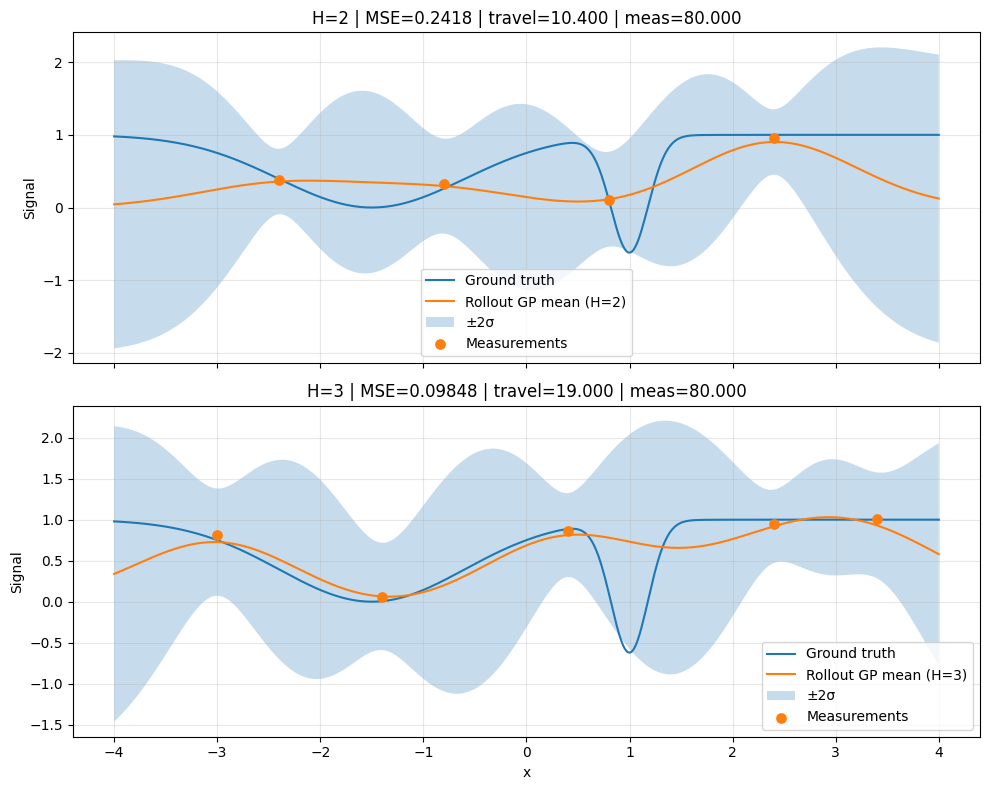

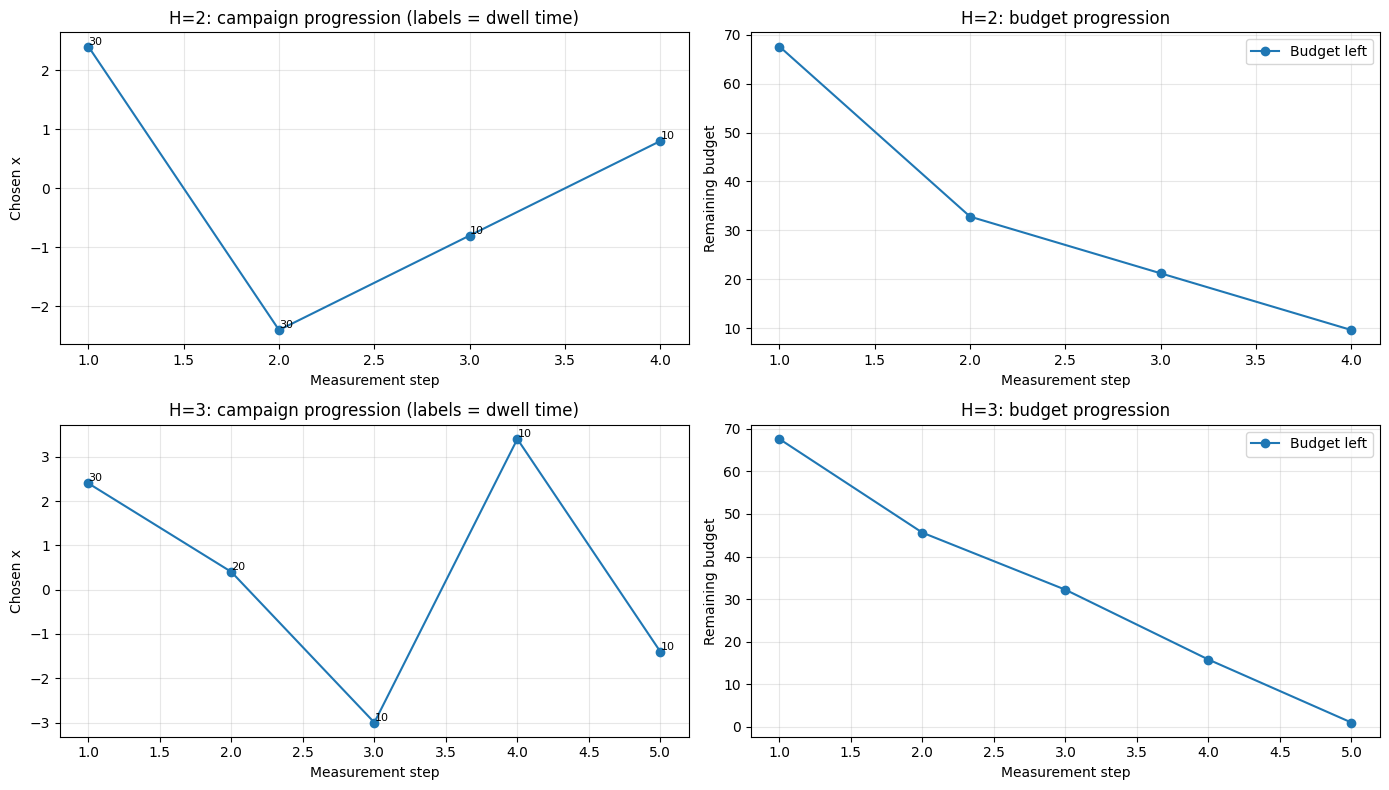

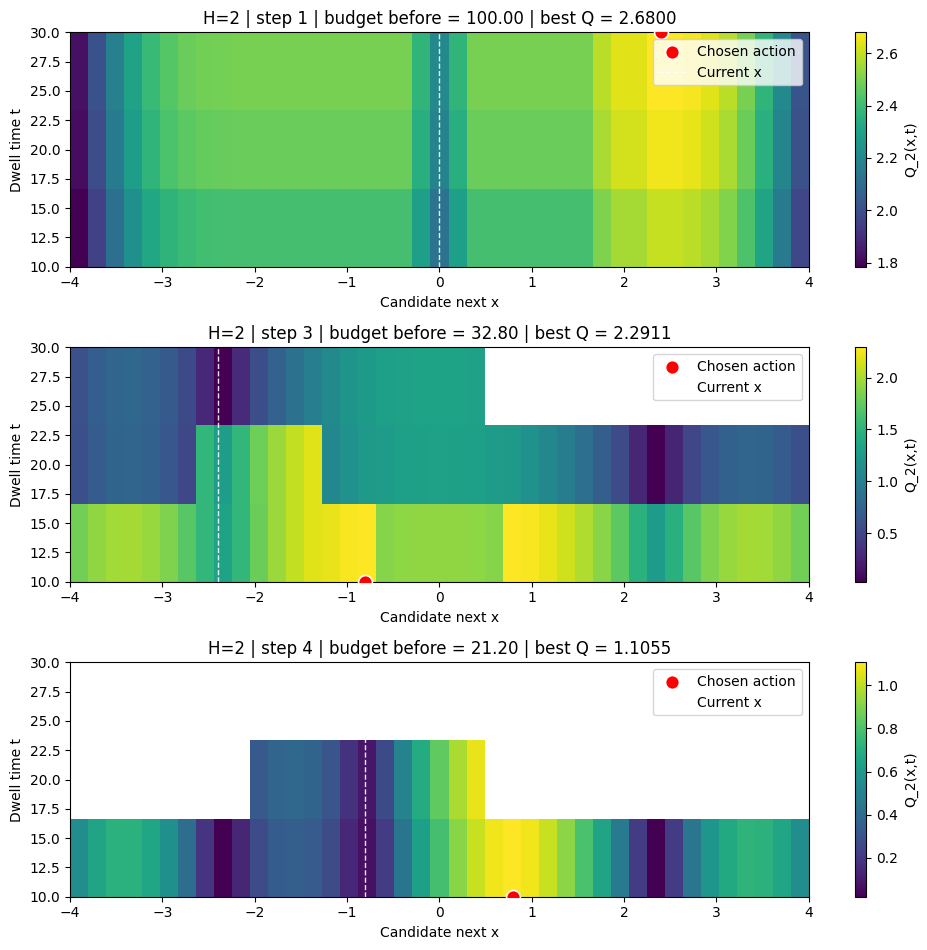

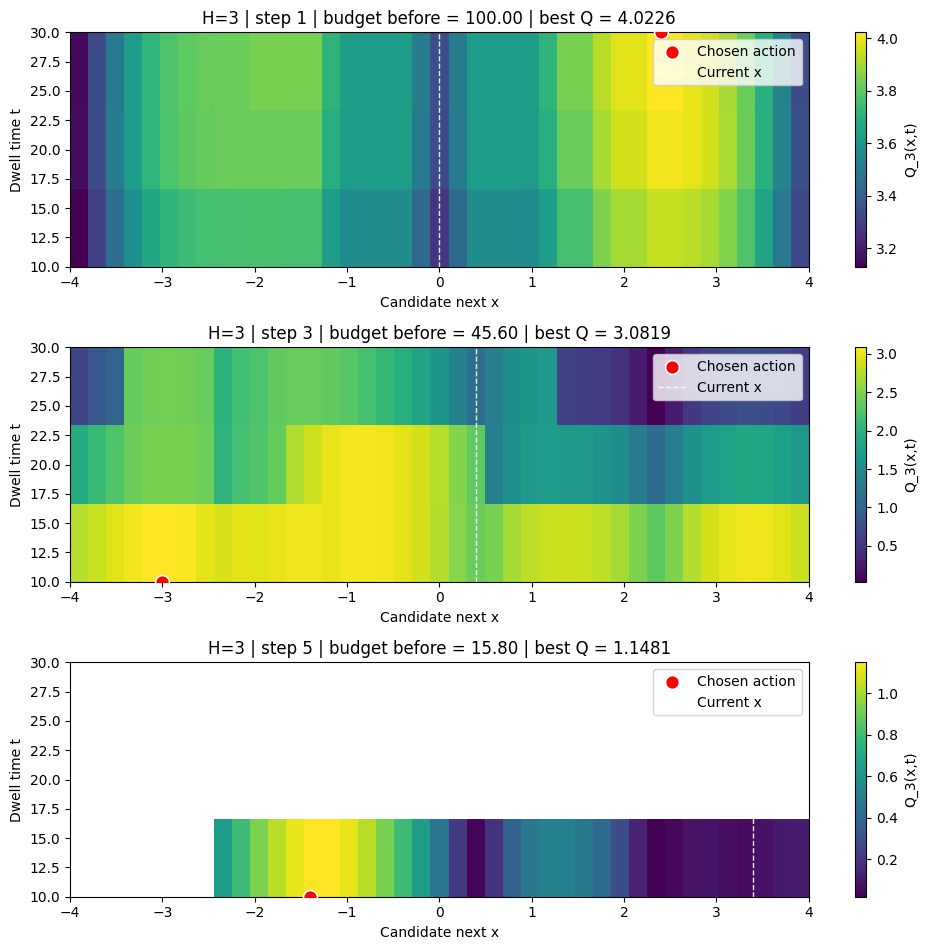

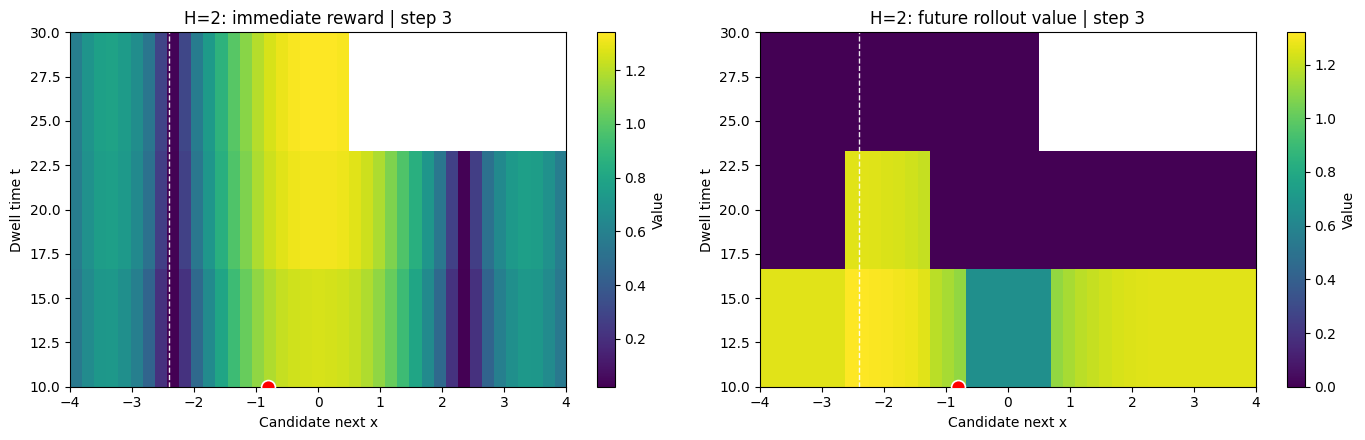

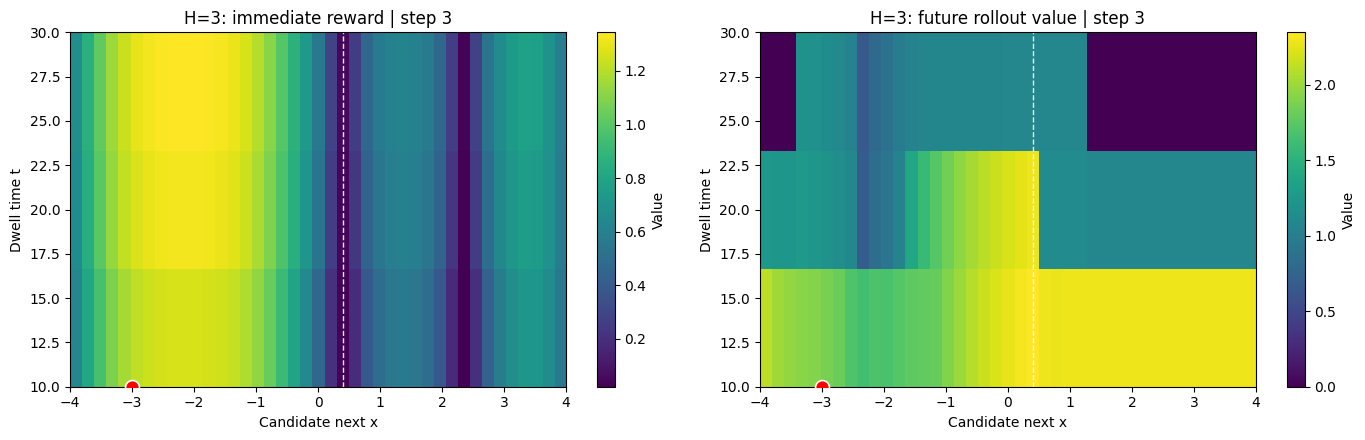

In [94]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# PARAMETERS
# ============================================================
TOTAL_BUDGET = B
X0 = 0.0
LAMBDA_TRAVEL = 1.0

# Rollout horizons to compare
HORIZONS = [2, 3]

# Candidate next-x grid used by the planner
CANDIDATE_X_POINTS = 41

# Utility-evaluation grid used to measure integrated uncertainty
UTILITY_X_POINTS = 81

# Allowed dwell times for actions
DWELL_CHOICES = np.array([10.0, 20.0, 30], dtype=float)

# To keep rollout tractable:
# for steps deeper than the first one, only consider top-K x points by variance
TOPK_FUTURE_X = 4

# GP / kernel used for planning and final reconstruction
KERNEL_VARIANCE = 1.0
KERNEL_LENGTHSCALE = 0.8
JITTER = 1e-8

# Assumed noise model for planning / reconstruction
# var(t) = NOISE_A / t^NOISE_ALPHA + NOISE_FLOOR
NOISE_A = 1.0
NOISE_ALPHA = 1.0
NOISE_FLOOR = 0.02

# Simulator
SIMULATOR_SEED = 123
GROUND_TRUTH_MODEL = broad_narrow
NOISE_MODEL = noise_decay_floor

# Visualization
STEPS_TO_VISUALIZE = 3   # per horizon: first / middle / last by default
CMAP = "viridis"

# ============================================================
# ASSUMPTIONS
# ============================================================
# Expected already in memory:
#   MeasurementSimulator
#   broad_narrow
#   noise_decay_floor
#   x_grid
# ============================================================

# ============================================================
# HELPER FUNCTIONS
# ============================================================
def rbf_kernel(x1, x2, variance=1.0, lengthscale=1.0):
    x1 = np.atleast_1d(x1).astype(float)[:, None]
    x2 = np.atleast_1d(x2).astype(float)[None, :]
    d2 = (x1 - x2) ** 2
    return variance * np.exp(-0.5 * d2 / (lengthscale ** 2))

def noise_var_from_t(t):
    t = np.asarray(t, dtype=float)
    return NOISE_A / np.maximum(t, 1e-12) ** NOISE_ALPHA + NOISE_FLOOR

def gp_posterior_predictive(x_train, y_train, noise_var_train, x_test,
                            variance=1.0, lengthscale=1.0, jitter=1e-8):
    x_train = np.asarray(x_train, dtype=float)
    y_train = np.asarray(y_train, dtype=float)
    noise_var_train = np.asarray(noise_var_train, dtype=float)
    x_test = np.asarray(x_test, dtype=float)

    if len(x_train) == 0:
        K_ss = rbf_kernel(x_test, x_test, variance, lengthscale)
        std = np.sqrt(np.clip(np.diag(K_ss), 0.0, None))
        mean = np.zeros_like(x_test)
        return mean, std

    K_tt = rbf_kernel(x_train, x_train, variance, lengthscale)
    K_tt = K_tt + np.diag(noise_var_train) + jitter * np.eye(len(x_train))
    K_ts = rbf_kernel(x_train, x_test, variance, lengthscale)
    K_ss = rbf_kernel(x_test, x_test, variance, lengthscale)

    alpha = np.linalg.solve(K_tt, y_train)
    mean = K_ts.T @ alpha

    v = np.linalg.solve(K_tt, K_ts)
    cov = K_ss - K_ts.T @ v
    std = np.sqrt(np.clip(np.diag(cov), 0.0, None))
    return mean, std

def trapz_weights_uniform(x):
    x = np.asarray(x, dtype=float)
    if len(x) == 1:
        return np.ones(1, dtype=float)
    dx = x[1] - x[0]
    w = np.full(len(x), dx, dtype=float)
    w[0] = dx / 2.0
    w[-1] = dx / 2.0
    return w

def covariance_update(C, obs_idx, noise_var):
    """
    Rank-1 posterior covariance update for one noisy observation of latent state
    corresponding to obs_idx in the joint covariance matrix C.
    """
    v = C[:, obs_idx].copy()
    denom = C[obs_idx, obs_idx] + noise_var
    C_new = C - np.outer(v, v) / denom
    return C_new, v, denom

# ============================================================
# ROLLOUT CORE
# ============================================================
def make_rollout_problem(x_domain_min, x_domain_max):
    candidate_x = np.linspace(x_domain_min, x_domain_max, CANDIDATE_X_POINTS)
    utility_x = np.linspace(x_domain_min, x_domain_max, UTILITY_X_POINTS)

    # Joint latent points:
    # first block   -> utility_x  (used to evaluate integrated variance)
    # second block  -> candidate_x (used as observation points)
    z_all = np.concatenate([utility_x, candidate_x])

    n_u = len(utility_x)
    n_c = len(candidate_x)

    C_prior = rbf_kernel(
        z_all, z_all,
        variance=KERNEL_VARIANCE,
        lengthscale=KERNEL_LENGTHSCALE
    )
    C_prior = C_prior + JITTER * np.eye(len(z_all))

    w_u = trapz_weights_uniform(utility_x)

    return {
        "candidate_x": candidate_x,
        "utility_x": utility_x,
        "z_all": z_all,
        "n_u": n_u,
        "n_c": n_c,
        "C_prior": C_prior,
        "w_u": w_u,
    }

def immediate_reward_from_update(v, denom, n_u, w_u):
    """
    Under utility U = - integrated variance,
    immediate reward is the reduction in integrated variance.
    """
    reduction_diag = (v[:n_u] ** 2) / denom
    return float(np.sum(w_u * reduction_diag))

def rollout_value(C, cur_x, budget_left, depth, problem):
    """
    Approximate N-step rollout value from current covariance C.

    At the first future branch below the actual chosen action, and deeper,
    only top-K candidate x by current variance are considered to control cost.
    """
    if depth <= 0:
        return 0.0

    candidate_x = problem["candidate_x"]
    n_u = problem["n_u"]
    w_u = problem["w_u"]

    min_action_cost = np.min(DWELL_CHOICES)
    if budget_left < min_action_cost - 1e-12:
        return 0.0

    # Posterior variances at candidate points (candidate block on the diagonal)
    cand_var = np.diag(C)[n_u:n_u + len(candidate_x)]

    # Keep only top-K x points by current variance
    topk = min(TOPK_FUTURE_X, len(candidate_x))
    top_idx = np.argsort(cand_var)[-topk:]

    best = 0.0
    for j in top_idx:
        xj = candidate_x[j]
        move_cost = LAMBDA_TRAVEL * abs(xj - cur_x)

        for t in DWELL_CHOICES:
            action_cost = float(t + move_cost)
            if action_cost > budget_left + 1e-12:
                continue

            obs_idx = n_u + j
            noise_var = float(noise_var_from_t(t))
            C_new, v, denom = covariance_update(C, obs_idx, noise_var)
            imm = immediate_reward_from_update(v, denom, n_u, w_u)
            fut = rollout_value(C_new, xj, budget_left - action_cost, depth - 1, problem)
            total = imm + fut

            if total > best:
                best = total

    return best

def first_action_value_grid(C, cur_x, budget_left, horizon, problem):
    """
    Evaluate Q_H(x,t) for all first actions on the full candidate grid.
    """
    candidate_x = problem["candidate_x"]
    n_u = problem["n_u"]
    w_u = problem["w_u"]

    Q_total = np.full((len(DWELL_CHOICES), len(candidate_x)), np.nan, dtype=float)
    Q_immediate = np.full_like(Q_total, np.nan)
    Q_future = np.full_like(Q_total, np.nan)

    best_action = None
    best_value = -np.inf

    for j, xj in enumerate(candidate_x):
        move_cost = LAMBDA_TRAVEL * abs(xj - cur_x)
        obs_idx = n_u + j

        for k, t in enumerate(DWELL_CHOICES):
            action_cost = float(t + move_cost)
            if action_cost > budget_left + 1e-12:
                continue

            noise_var = float(noise_var_from_t(t))
            C_new, v, denom = covariance_update(C, obs_idx, noise_var)
            imm = immediate_reward_from_update(v, denom, n_u, w_u)
            fut = rollout_value(C_new, xj, budget_left - action_cost, horizon - 1, problem)
            total = imm + fut

            Q_total[k, j] = total
            Q_immediate[k, j] = imm
            Q_future[k, j] = fut

            if total > best_value:
                best_value = total
                best_action = {
                    "x": float(xj),
                    "t": float(t),
                    "move_cost": float(move_cost),
                    "action_cost": float(action_cost),
                    "obs_idx": int(obs_idx),
                    "noise_var": float(noise_var),
                    "Q_total": float(total),
                    "Q_immediate": float(imm),
                    "Q_future": float(fut),
                }

    return Q_total, Q_immediate, Q_future, best_action

# ============================================================
# EXECUTE RECEDING-HORIZON CAMPAIGN
# ============================================================
def run_receding_horizon_campaign(horizon, problem):
    meas_sim = MeasurementSimulator(
        ground_truth_model=GROUND_TRUTH_MODEL,
        noise_model=NOISE_MODEL,
        rng=SIMULATOR_SEED,
    )

    C_current = problem["C_prior"].copy()
    candidate_x = problem["candidate_x"]

    x_obs, y_obs, t_obs = [], [], []
    history = []

    cur_x = float(X0)
    budget_left = float(TOTAL_BUDGET)
    step = 0

    while True:
        min_possible_move = np.min(np.abs(candidate_x - cur_x)) * LAMBDA_TRAVEL
        if budget_left < np.min(DWELL_CHOICES) + min_possible_move - 1e-12:
            break

        Q_total, Q_immediate, Q_future, best = first_action_value_grid(
            C=C_current,
            cur_x=cur_x,
            budget_left=budget_left,
            horizon=horizon,
            problem=problem,
        )

        if best is None:
            break

        # Execute only the first action on the simulator
        y_new = float(meas_sim.measure(np.array([[best["x"], best["t"]]]))[0])

        # Update covariance state using the planned noisy observation model
        C_current, _, _ = covariance_update(C_current, best["obs_idx"], best["noise_var"])

        x_obs.append(best["x"])
        y_obs.append(y_new)
        t_obs.append(best["t"])

        step += 1
        history.append({
            "step": step,
            "x": float(best["x"]),
            "t": float(best["t"]),
            "y": float(y_new),
            "cur_x_before": float(cur_x),
            "move_cost": float(best["move_cost"]),
            "action_cost": float(best["action_cost"]),
            "budget_left_before": float(budget_left),
            "budget_left_after": float(budget_left - best["action_cost"]),
            "Q_total": Q_total.copy(),
            "Q_immediate": Q_immediate.copy(),
            "Q_future": Q_future.copy(),
            "best_total_value": float(best["Q_total"]),
            "best_immediate_value": float(best["Q_immediate"]),
            "best_future_value": float(best["Q_future"]),
        })

        cur_x = float(best["x"])
        budget_left -= float(best["action_cost"])

    x_obs = np.asarray(x_obs, dtype=float)
    y_obs = np.asarray(y_obs, dtype=float)
    t_obs = np.asarray(t_obs, dtype=float)

    # Final reconstruction on the full x_grid using actual observed y
    noise_vars = noise_var_from_t(t_obs) if len(t_obs) > 0 else np.array([])
    mean_pred, std_pred = gp_posterior_predictive(
        x_train=x_obs,
        y_train=y_obs,
        noise_var_train=noise_vars,
        x_test=x_grid,
        variance=KERNEL_VARIANCE,
        lengthscale=KERNEL_LENGTHSCALE,
        jitter=JITTER,
    )

    y_true = np.asarray(GROUND_TRUTH_MODEL(x_grid), dtype=float)
    mse = float(np.mean((mean_pred - y_true) ** 2)) if len(x_obs) > 0 else np.nan

    total_travel = float(np.sum([h["move_cost"] for h in history]))
    total_measurement = float(np.sum(t_obs))
    total_cost = total_travel + total_measurement

    return {
        "horizon": int(horizon),
        "x_obs": x_obs,
        "y_obs": y_obs,
        "t_obs": t_obs,
        "history": history,
        "mean_pred": mean_pred,
        "std_pred": std_pred,
        "y_true": y_true,
        "mse": mse,
        "budget_left": float(budget_left),
        "total_travel": total_travel,
        "total_measurement": total_measurement,
        "total_cost": total_cost,
        "problem": problem,
    }

# ============================================================
# RUN H=2 AND H=3
# ============================================================
problem = make_rollout_problem(float(np.min(x_grid)), float(np.max(x_grid)))

results = {}
for H in HORIZONS:
    results[H] = run_receding_horizon_campaign(H, problem)

# ============================================================
# PRINT SUMMARY
# ============================================================
for H in HORIZONS:
    r = results[H]
    print(f"\n=== Horizon H = {H} ===")
    print(f"Measurements taken    : {len(r['x_obs'])}")
    print(f"Total travel cost     : {r['total_travel']:.6f}")
    print(f"Total measurement time: {r['total_measurement']:.6f}")
    print(f"Total realized cost   : {r['total_cost']:.6f}")
    print(f"Unused budget         : {r['budget_left']:.6f}")
    print(f"Final reconstruction MSE: {r['mse']:.6g}")

# ============================================================
# PLOT 1: FINAL RECONSTRUCTIONS
# ============================================================
fig, axes = plt.subplots(len(HORIZONS), 1, figsize=(10, 4 * len(HORIZONS)), sharex=True)
if len(HORIZONS) == 1:
    axes = [axes]

for ax, H in zip(axes, HORIZONS):
    r = results[H]
    ax.plot(x_grid, r["y_true"], label="Ground truth")
    ax.plot(x_grid, r["mean_pred"], label=f"Rollout GP mean (H={H})")
    ax.fill_between(
        x_grid,
        r["mean_pred"] - 2.0 * r["std_pred"],
        r["mean_pred"] + 2.0 * r["std_pred"],
        alpha=0.25,
        label="±2σ"
    )
    ax.scatter(r["x_obs"], r["y_obs"], s=45, zorder=3, label="Measurements")
    ax.set_ylabel("Signal")
    ax.set_title(
        f"H={H} | MSE={r['mse']:.4g} | travel={r['total_travel']:.3f} | meas={r['total_measurement']:.3f}"
    )
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")

axes[-1].set_xlabel("x")
plt.tight_layout()
plt.show()

# ============================================================
# PLOT 2: PROGRESSION
# ============================================================
fig, axes = plt.subplots(len(HORIZONS), 2, figsize=(14, 4 * len(HORIZONS)))
if len(HORIZONS) == 1:
    axes = np.array([axes])

for row, H in enumerate(HORIZONS):
    r = results[H]
    steps = np.arange(1, len(r["x_obs"]) + 1)

    # Path progression
    ax = axes[row, 0]
    ax.plot(steps, r["x_obs"], marker="o")
    for s, x, t in zip(steps, r["x_obs"], r["t_obs"]):
        ax.text(s, x, f"{t:.0f}", fontsize=8, ha="left", va="bottom")
    ax.set_xlabel("Measurement step")
    ax.set_ylabel("Chosen x")
    ax.set_title(f"H={H}: campaign progression (labels = dwell time)")
    ax.grid(True, alpha=0.3)

    # Budget progression
    ax = axes[row, 1]
    budget_after = np.array([h["budget_left_after"] for h in r["history"]], dtype=float)
    ax.plot(steps, budget_after, marker="o", label="Budget left")
    ax.set_xlabel("Measurement step")
    ax.set_ylabel("Remaining budget")
    ax.set_title(f"H={H}: budget progression")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")

plt.tight_layout()
plt.show()

# ============================================================
# PLOT 3: VALUE FUNCTION HEATMAPS Q_H(x,t)
# ============================================================
def select_step_indices_for_plot(n_steps, n_show):
    if n_steps == 0:
        return []
    if n_steps <= n_show:
        return list(range(n_steps))
    idx = np.linspace(0, n_steps - 1, n_show).round().astype(int)
    return list(np.unique(idx))

for H in HORIZONS:
    r = results[H]
    candidate_x = r["problem"]["candidate_x"]
    history = r["history"]
    idx_show = select_step_indices_for_plot(len(history), STEPS_TO_VISUALIZE)

    if len(idx_show) == 0:
        continue

    fig, axes = plt.subplots(len(idx_show), 1, figsize=(10, 3.2 * len(idx_show)), squeeze=False)

    for ax, idx in zip(axes[:, 0], idx_show):
        h = history[idx]
        Q = h["Q_total"]

        im = ax.imshow(
            Q,
            origin="lower",
            aspect="auto",
            cmap=CMAP,
            extent=[candidate_x.min(), candidate_x.max(), DWELL_CHOICES.min(), DWELL_CHOICES.max()],
        )

        ax.scatter(
            [h["x"]], [h["t"]],
            s=100, c="red", edgecolors="white", linewidths=1.2,
            label="Chosen action", zorder=3
        )
        ax.axvline(h["cur_x_before"], color="white", linestyle="--", linewidth=1.0, alpha=0.9,
                   label="Current x")

        ax.set_title(
            f"H={H} | step {h['step']} | budget before = {h['budget_left_before']:.2f} | "
            f"best Q = {h['best_total_value']:.4f}"
        )
        ax.set_xlabel("Candidate next x")
        ax.set_ylabel("Dwell time t")
        ax.legend(loc="upper right")

        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label(f"Q_{H}(x,t)")

    plt.tight_layout()
    plt.show()

# ============================================================
# PLOT 4: IMMEDIATE vs FUTURE VALUE FOR ONE REPRESENTATIVE STEP
# ============================================================
for H in HORIZONS:
    r = results[H]
    history = r["history"]
    if len(history) == 0:
        continue

    idx_mid = len(history) // 2
    h = history[idx_mid]
    candidate_x = r["problem"]["candidate_x"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

    for ax, title, Q in zip(
        axes,
        [f"H={H}: immediate reward", f"H={H}: future rollout value"],
        [h["Q_immediate"], h["Q_future"]],
    ):
        im = ax.imshow(
            Q,
            origin="lower",
            aspect="auto",
            cmap=CMAP,
            extent=[candidate_x.min(), candidate_x.max(), DWELL_CHOICES.min(), DWELL_CHOICES.max()],
        )
        ax.scatter(
            [h["x"]], [h["t"]],
            s=100, c="red", edgecolors="white", linewidths=1.2, zorder=3
        )
        ax.axvline(h["cur_x_before"], color="white", linestyle="--", linewidth=1.0, alpha=0.9)
        ax.set_title(title + f" | step {h['step']}")
        ax.set_xlabel("Candidate next x")
        ax.set_ylabel("Dwell time t")
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label("Value")

    plt.tight_layout()
    plt.show()